# Exploratory Data Analysis: Google Political Ads TEXT Dataset

This notebook provides a comprehensive analysis of the Google political ads text dataset, with a focus on:
1. **Dataset Quality Assessment** - Missing values, data quality issues
2. **Text Content Analysis** - All advertisement text sources
3. **NLP Usability Assessment** - Whether the data is suitable for NLP tasks
4. **Text Source Comparison** - Actual ad text vs extracted text (OCR/ASR)

## Dataset Overview
- **Source**: Google Ad Transparency 2022 - Text Content
- **Purpose**: Analyze ad text for manipulation detection
- **Rows**: ~99,524 ads


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
import re
from collections import Counter
from wordcloud import WordCloud

# NLP libraries
try:
    from textblob import TextBlob
    TEXTBLOB_AVAILABLE = True
except ImportError:
    TEXTBLOB_AVAILABLE = False
    print("TextBlob not available. Install with: pip install textblob")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None)  # Show full text

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load the Google text dataset
data_path = '../../data/google/g2022_adid_text_040825.csv'
df = pd.read_csv(data_path, low_memory=False)

print("=" * 80)
print("DATASET LOADING")
print("=" * 80)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Columns: {len(df.columns)}")
print(f"Rows: {len(df):,}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


DATASET LOADING
Dataset shape: (80247, 12)
Memory usage: 139.84 MB
Columns: 12
Rows: 80,247

Column names:
   1. ad_id
   2. advertiser_name
   3. ad_url
   4. all_urls
   5. ad_type
   6. ad_title
   7. ad_text
   8. google_asr_text
   9. aws_ocr_img_text
  10. aws_ocr_video_text
  11. description
  12. checksum


In [3]:
# Display first few rows to understand structure
print("=" * 80)
print("DATASET STRUCTURE - FIRST FEW ROWS")
print("=" * 80)
df.head()


DATASET STRUCTURE - FIRST FEW ROWS


,ad_id,advertiser_name,ad_url,all_urls,ad_type,ad_title,ad_text,google_asr_text,aws_ocr_img_text,aws_ocr_video_text,description,checksum
0,CR00000257354440376321,Abrams For Governor,https://adstransparency.google.com/advertiser/AR08588079303567081473/creative/CR00000257354440376321?political=&region=US,NaN,VIDEO,NaN,NaN,"Democratic candidate for governor. Stacey Abrams is calling for another round of payments to Georgia taxpayers. She's calling on current Governor Brian Kemp to make these payments using Federal covid-19 money specifically Abrams wants to expand Medicaid, coverage, to all adults, increase pay for teachers, and law enforcement, and not increased taxes.",NaN,"» RECORDED FOX31 STACEYABRAMS GOVERNOR Specifically, Abrams wants to expand Medicaid coverage to all adults, FOX31 » RECORDED WFXL Democratic candidate for governor Stacey Abrams is calling » RECORDED FOX31 WFXL and not increase taxes PAID FOR BY ABRAMS FOR GOVERNOR » RECORDED FOX31 WFXL Specifically, Abrams wants to expand Medicaid coverage to all adults, » RECORDED FOX31 WFXL She is calling on current Governor Brian Kemp » RECORDED FOX31 WFXL to make these payments using federal COVID-19 money. » RECORDED FOX31 WFXL for another round of payments to Georgia taxpayers. » RECORDED FOX31 WFXL STACEYABRAMS GOVERNOR Specifically, Abrams wants to expand Medicaid coverage to all adults, FOX31 » RECORDED WFXL VICTORIA DE CARDENAS f @VICTORIAWGXA Democratic candidate for governor Stacey Abrams is calling » RECORDED ECTING PEOPLE WITH CONTENT EVERYWHERE CONNECTING PEOPLE GEORGIA NEWS Democratic candidate for governor Stacey Abrams is calling » RECORDED VERYWHERE CONNECTING PEOPLE WITH CONTENT EVERYWHERE GEORGIA NEWS » RECORDED FOX31 WFXL increase pay for teachers and law enforcement, » RECORDED FOX31 POLICE POLICE increase pay for teachers and law enforcement, PAID FOR BY ABRAMS FOR GOVERNOR » RECORDED FOX31 WFXL POLICE POLICE and not increase taxes PAID FOR BY ABRAMS FOR GOVERNOR",NaN,3a0b45af177cfef8675852003ebb1e57838275d50d20b6f1cf9d45a7329cb16d
1,CR00000354386341527553,PROGRESSNOW COLORADO,https://adstransparency.google.com/advertiser/AR03715945093920718849/creative/CR00000354386341527553?political=&region=US,www.progressivevoters.guide/,TEXT,Colorado Proposition GG,Learn About Colorado Proposition GG Concerning Tax Transparency On Ballot Initiatives,NaN,NaN,NaN,NaN,NaN
2,CR00000501995777556481,KEVIN COMBS,https://adstransparency.google.com/advertiser/AR01324533691786985473/creative/CR00000501995777556481?political=&region=US,https://theblueballot.com/stim/,IMAGE,NaN,1 Message Pending\nView Pending Messages\nNow,NaN,2 9 10 8 7 11 1.2 6 5 1 4 3,NaN,NaN,5e7c33fc965c222ab5ad92a4b26e9be7938f271faa96bc5d53628f2751bc76fc
3,CR00000912113614716929,KEVIN COMBS,https://adstransparency.google.com/advertiser/AR01324533691786985473/creative/CR00000912113614716929?political=&region=US,NaN,IMAGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CR00001130641550737409,HOUSE REPUBLICAN CAMPAIGN COMMITTEE,https://adstransparency.google.com/advertiser/AR00793108935757266945/creative/CR00001130641550737409?political=&region=US,NaN,VIDEO,NaN,NaN,Dr. Micha Yelawolf fully fund our law enforcement and fight back against pro-abortion legislation.,NaN,"DR For PAID FOR, WITH REGULATED FUNDS, BY HOUSE REPUBLICAN CAMPAIGN COMMITTEE AUTHORIZED BY MIKE AIELLO. DR MIKE AIELLO For State Representative PAID FOR, WITH REGULATED FUNDS, BY HOUSE REPUBLICAN CAMPAIGN COMMITTEE AUTHORIZED BY MIKE AIELLO. DR MIKE AIELLO FUNDING OUR POLICE PAID FOR, WITH.REGULATED FUNDS, BY HOUSE REPUBLICAN CAMPAIGN COMMITTEE AUTHORIZED BY MIKE AIELLO. DR MIKE AIELLO FUNDING OUR POLICE PAID FOR, FUNDS, BY HOUSE REPUBLICAN CAMPAIGN COMMITTEE AUTHORIZED BY MIKE AIELLO. PAID FOR, WITH REGULATED FUNDS, BY HOUSE REPUBLICAN CAMPAIGN COMMITTEE AUTHORIZED BY MIKE AIELLO.",NaN,05badf6f800846cdd009b132b06ed6fa15f6e00d88b578cbd307cc62c34db5fc


MISSING VALUES ANALYSIS - COMPREHENSIVE

Missing Values Summary:
            Column  Null_Count  Null_Pct  Empty_String_Count  Empty_String_Pct  Total_Missing  Total_Missing_Pct  Non_Empty  Non_Empty_Pct
       description       80122 99.844231                   0          0.000000          80122          99.844231        125       0.155769
          ad_title       65009 81.011128                   0          0.000000          65009          81.011128      15238      18.988872
  aws_ocr_img_text       62468 77.844655                   1          0.001246          62469          77.845901      17778      22.154099
           ad_text       58097 72.397722                   0          0.000000          58097          72.397722      22150      27.602278
          all_urls       46992 58.559198                   0          0.000000          46992          58.559198      33255      41.440802
   google_asr_text       45352 56.515508                 533          0.664199          45885        

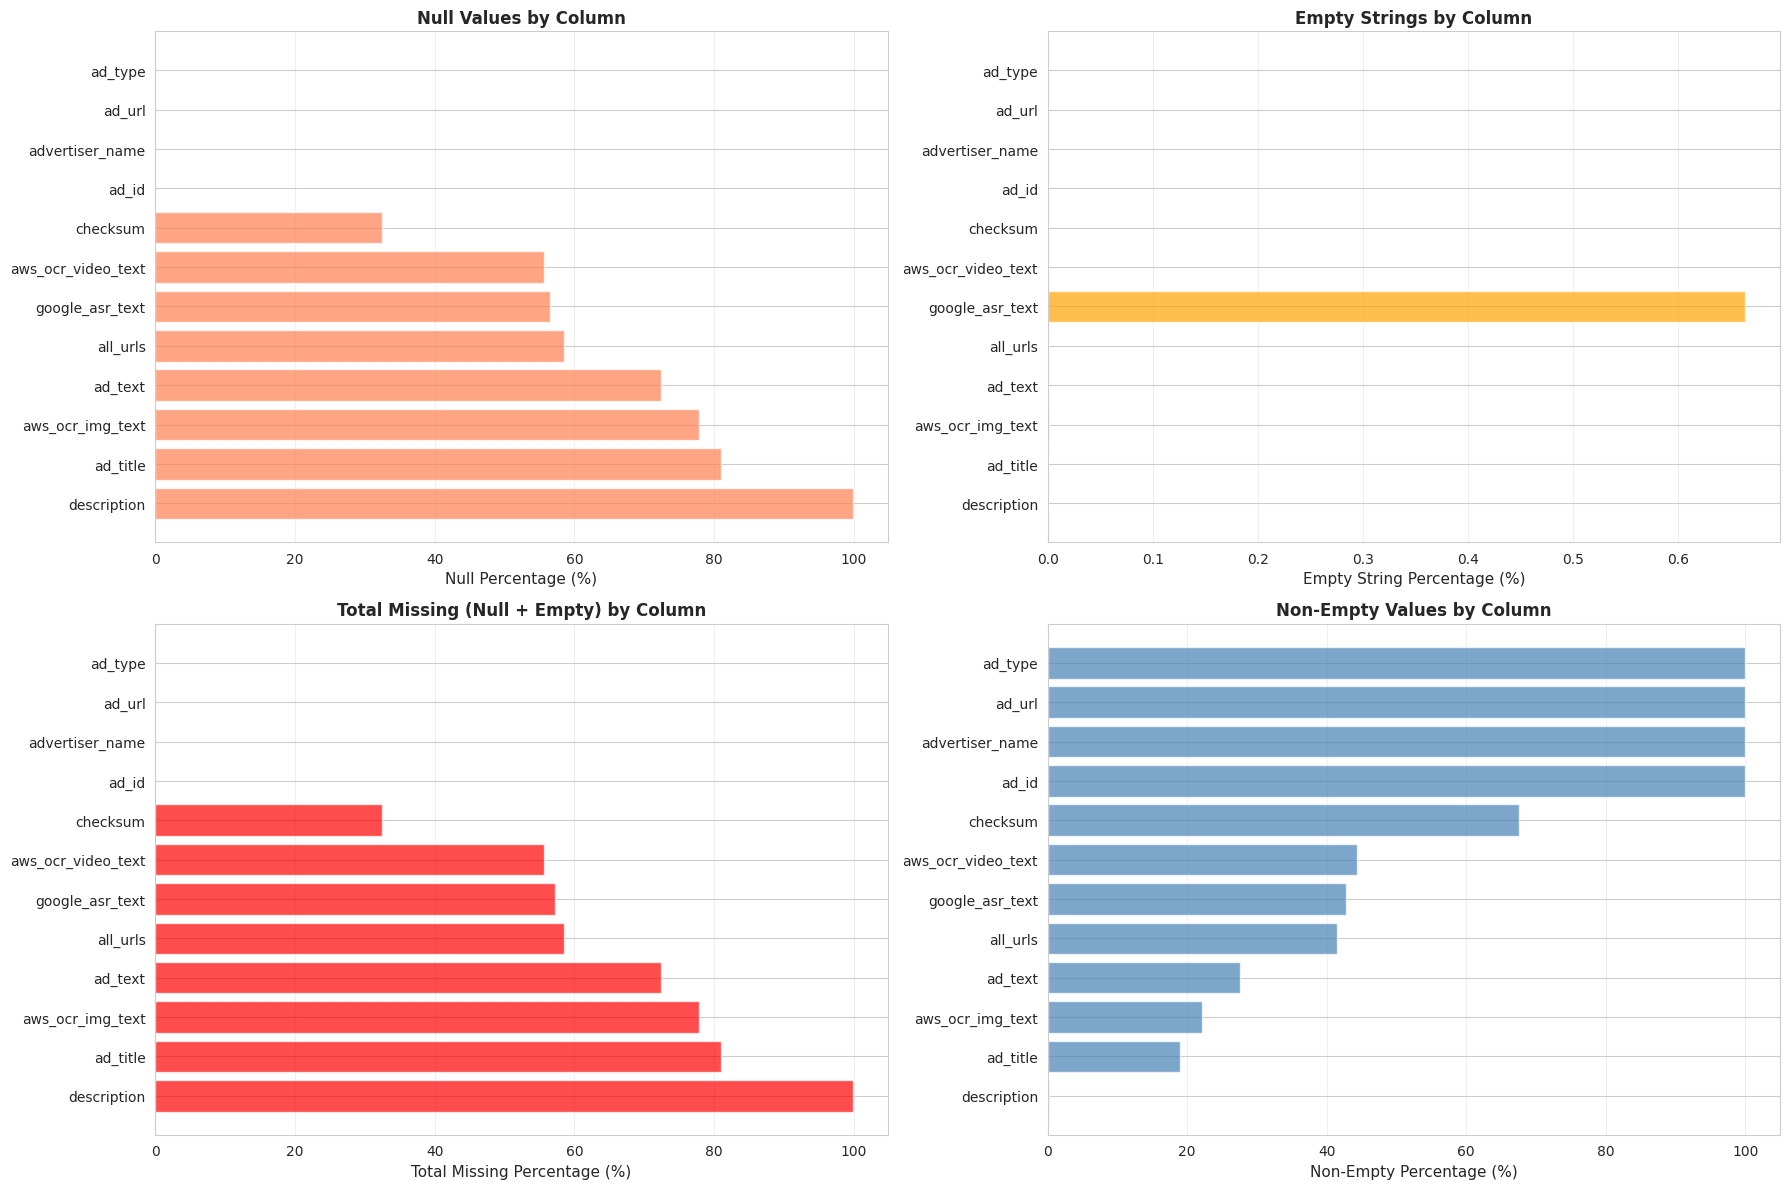


POTENTIAL DATA QUALITY ISSUES

⚠️  Columns with >50% missing data (7):
  - description: 99.8% missing
  - ad_title: 81.0% missing
  - aws_ocr_img_text: 77.8% missing
  - ad_text: 72.4% missing
  - all_urls: 58.6% missing
  - google_asr_text: 57.2% missing
  - aws_ocr_video_text: 55.6% missing

✓  Columns with <5% missing data (4):
  - ad_id: 0.0% missing
  - advertiser_name: 0.0% missing
  - ad_url: 0.0% missing
  - ad_type: 0.0% missing


In [4]:
# COMPREHENSIVE MISSING VALUES ANALYSIS
print("=" * 80)
print("MISSING VALUES ANALYSIS - COMPREHENSIVE")
print("=" * 80)

# Calculate missing values for all columns
missing_analysis = []
for col in df.columns:
    missing_count = df[col].isna().sum()
    missing_pct = (missing_count / len(df)) * 100
    
    # Check for empty strings (which might be considered "missing" for text)
    if df[col].dtype == 'object':
        empty_strings = (df[col].astype(str).str.strip() == '').sum()
        empty_pct = (empty_strings / len(df)) * 100
    else:
        empty_strings = 0
        empty_pct = 0
    
    # Total "missing" (null + empty strings)
    total_missing = missing_count + empty_strings
    total_missing_pct = (total_missing / len(df)) * 100
    
    # Non-empty count
    non_empty = len(df) - total_missing
    non_empty_pct = 100 - total_missing_pct
    
    missing_analysis.append({
        'Column': col,
        'Null_Count': missing_count,
        'Null_Pct': missing_pct,
        'Empty_String_Count': empty_strings,
        'Empty_String_Pct': empty_pct,
        'Total_Missing': total_missing,
        'Total_Missing_Pct': total_missing_pct,
        'Non_Empty': non_empty,
        'Non_Empty_Pct': non_empty_pct
    })

missing_df = pd.DataFrame(missing_analysis)
missing_df = missing_df.sort_values('Total_Missing_Pct', ascending=False)

print("\nMissing Values Summary:")
print(missing_df.to_string(index=False))

# Visualize missing values
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Null values
axes[0, 0].barh(missing_df['Column'], missing_df['Null_Pct'], color='coral', alpha=0.7)
axes[0, 0].set_xlabel('Null Percentage (%)', fontsize=11)
axes[0, 0].set_title('Null Values by Column', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Empty strings
axes[0, 1].barh(missing_df['Column'], missing_df['Empty_String_Pct'], color='orange', alpha=0.7)
axes[0, 1].set_xlabel('Empty String Percentage (%)', fontsize=11)
axes[0, 1].set_title('Empty Strings by Column', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Total missing
axes[1, 0].barh(missing_df['Column'], missing_df['Total_Missing_Pct'], color='red', alpha=0.7)
axes[1, 0].set_xlabel('Total Missing Percentage (%)', fontsize=11)
axes[1, 0].set_title('Total Missing (Null + Empty) by Column', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Non-empty
axes[1, 1].barh(missing_df['Column'], missing_df['Non_Empty_Pct'], color='steelblue', alpha=0.7)
axes[1, 1].set_xlabel('Non-Empty Percentage (%)', fontsize=11)
axes[1, 1].set_title('Non-Empty Values by Column', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Identify potential data quality issues
print("\n" + "=" * 80)
print("POTENTIAL DATA QUALITY ISSUES")
print("=" * 80)

high_missing = missing_df[missing_df['Total_Missing_Pct'] > 50]
if len(high_missing) > 0:
    print(f"\n⚠️  Columns with >50% missing data ({len(high_missing)}):")
    for _, row in high_missing.iterrows():
        print(f"  - {row['Column']}: {row['Total_Missing_Pct']:.1f}% missing")

low_missing = missing_df[missing_df['Total_Missing_Pct'] < 5]
if len(low_missing) > 0:
    print(f"\n✓  Columns with <5% missing data ({len(low_missing)}):")
    for _, row in low_missing.iterrows():
        print(f"  - {row['Column']}: {row['Total_Missing_Pct']:.1f}% missing")


TEXT COLUMNS ANALYSIS - Understanding Text Sources

Text Column Definitions:
  ad_text                  : Actual ad text (primary text content)
  ad_title                 : Ad title/headline
  description              : Ad description
  google_asr_text          : Speech-to-text extracted from video (ASR)
  aws_ocr_img_text         : Text extracted from images (OCR)
  aws_ocr_video_text       : Text extracted from video frames (OCR)

DETAILED TEXT COLUMN STATISTICS

Text Statistics:
            Column  Non_Empty_Count  Non_Empty_Pct  Mean_Length  Median_Length  Min_Length  Max_Length  Mean_Words  Median_Words
aws_ocr_video_text            35635      44.406644  1551.515168          899.0           1       60342  256.861344         147.0
   google_asr_text            34362      42.820292   386.021099          260.0           3       34123   66.705547          45.0
           ad_text            22150      27.602278    77.904063           76.0           9         357   12.626637          12

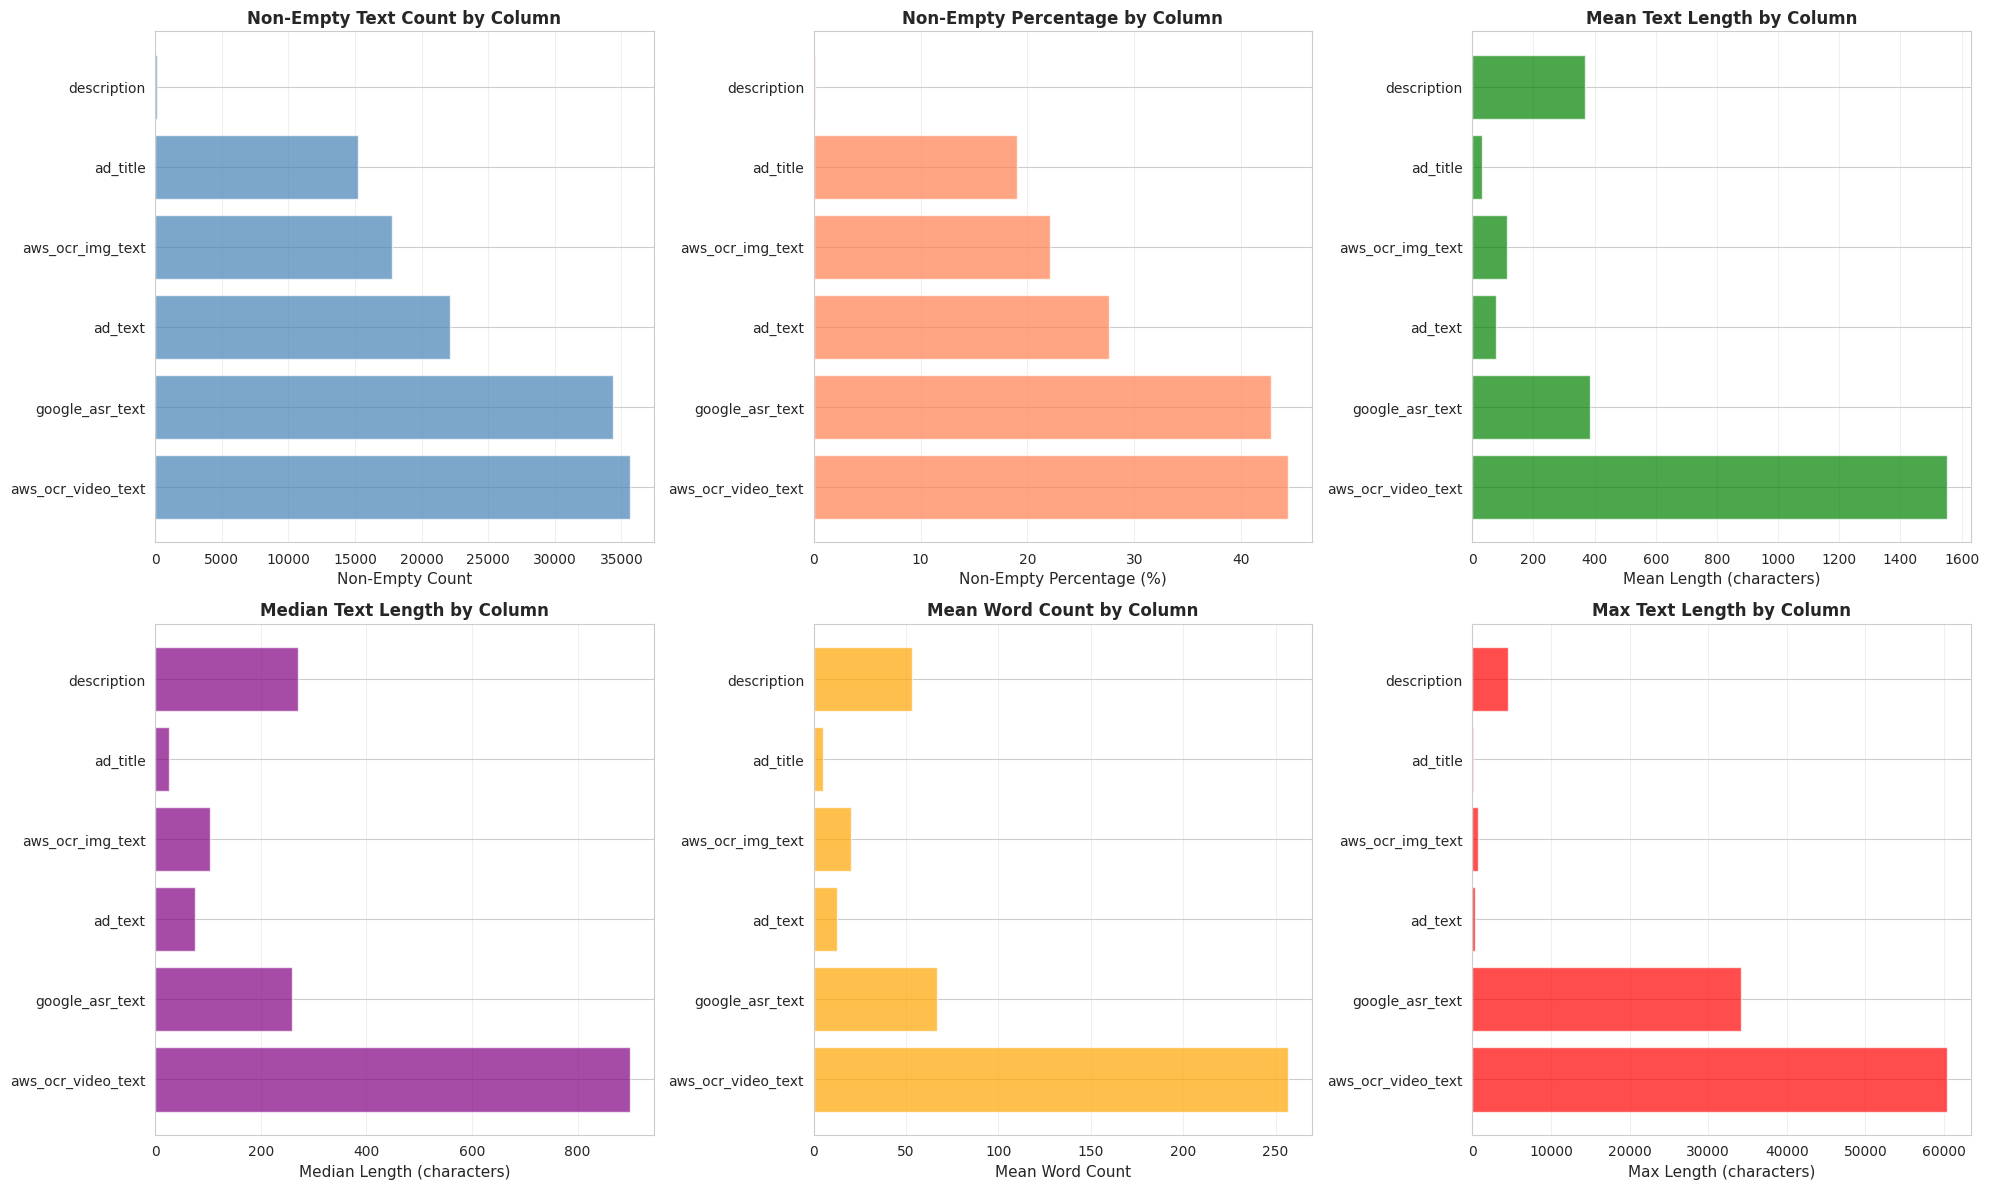

In [6]:
# TEXT COLUMNS ANALYSIS - Understanding text sources
print("=" * 80)
print("TEXT COLUMNS ANALYSIS - Understanding Text Sources")
print("=" * 80)

# Define text columns
text_columns = {
    'ad_text': 'Actual ad text (primary text content)',
    'ad_title': 'Ad title/headline',
    'description': 'Ad description',
    'google_asr_text': 'Speech-to-text extracted from video (ASR)',
    'aws_ocr_img_text': 'Text extracted from images (OCR)',
    'aws_ocr_video_text': 'Text extracted from video frames (OCR)'
}

print("\nText Column Definitions:")
for col, desc in text_columns.items():
    if col in df.columns:
        print(f"  {col:25s}: {desc}")

# Analyze each text column
print("\n" + "=" * 80)
print("DETAILED TEXT COLUMN STATISTICS")
print("=" * 80)

text_stats = []
for col in text_columns.keys():
    if col in df.columns:
        # Get non-empty values
        non_empty = df[col].dropna()
        non_empty = non_empty[non_empty.astype(str).str.strip() != '']
        
        if len(non_empty) > 0:
            lengths = non_empty.astype(str).str.len()
            word_counts = non_empty.astype(str).str.split().str.len()
            
            text_stats.append({
                'Column': col,
                'Non_Empty_Count': len(non_empty),
                'Non_Empty_Pct': (len(non_empty) / len(df)) * 100,
                'Mean_Length': lengths.mean(),
                'Median_Length': lengths.median(),
                'Min_Length': lengths.min(),
                'Max_Length': lengths.max(),
                'Mean_Words': word_counts.mean(),
                'Median_Words': word_counts.median()
            })

text_stats_df = pd.DataFrame(text_stats)
text_stats_df = text_stats_df.sort_values('Non_Empty_Count', ascending=False)

print("\nText Statistics:")
print(text_stats_df.to_string(index=False))

# Visualize text column statistics
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes[0, 0].barh(text_stats_df['Column'], text_stats_df['Non_Empty_Count'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Non-Empty Count', fontsize=11)
axes[0, 0].set_title('Non-Empty Text Count by Column', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

axes[0, 1].barh(text_stats_df['Column'], text_stats_df['Non_Empty_Pct'], color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Non-Empty Percentage (%)', fontsize=11)
axes[0, 1].set_title('Non-Empty Percentage by Column', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

axes[0, 2].barh(text_stats_df['Column'], text_stats_df['Mean_Length'], color='green', alpha=0.7)
axes[0, 2].set_xlabel('Mean Length (characters)', fontsize=11)
axes[0, 2].set_title('Mean Text Length by Column', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='x')

axes[1, 0].barh(text_stats_df['Column'], text_stats_df['Median_Length'], color='purple', alpha=0.7)
axes[1, 0].set_xlabel('Median Length (characters)', fontsize=11)
axes[1, 0].set_title('Median Text Length by Column', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

axes[1, 1].barh(text_stats_df['Column'], text_stats_df['Mean_Words'], color='orange', alpha=0.7)
axes[1, 1].set_xlabel('Mean Word Count', fontsize=11)
axes[1, 1].set_title('Mean Word Count by Column', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

axes[1, 2].barh(text_stats_df['Column'], text_stats_df['Max_Length'], color='red', alpha=0.7)
axes[1, 2].set_xlabel('Max Length (characters)', fontsize=11)
axes[1, 2].set_title('Max Text Length by Column', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


In [7]:
# SHOW ALL AD TEXT CONTENT - Full text display
print("=" * 80)
print("FULL AD TEXT CONTENT - ALL TEXT SOURCES")
print("=" * 80)

# Get rows with substantial text content
def has_substantial_text(row):
    """Check if row has substantial text in any column"""
    text_cols = ['ad_text', 'ad_title', 'description', 'google_asr_text', 
                 'aws_ocr_img_text', 'aws_ocr_video_text']
    for col in text_cols:
        if col in df.columns:
            val = row.get(col)
            if pd.notna(val) and str(val).strip() != '' and len(str(val).strip()) > 20:
                return True
    return False

# Filter to rows with substantial text
df_with_text = df[df.apply(has_substantial_text, axis=1)].copy()

print(f"\nRows with substantial text (>20 chars): {len(df_with_text):,} ({len(df_with_text)/len(df)*100:.1f}%)")
print(f"\nShowing first 15 ads with full text content:\n")

# Display full text for first 15 ads
for idx, (row_idx, row) in enumerate(df_with_text.head(15).iterrows(), 1):
    print("=" * 100)
    print(f"AD #{idx} (Row {row_idx})")
    print("=" * 100)
    print(f"Ad ID: {row.get('ad_id', 'N/A')}")
    print(f"Advertiser: {row.get('advertiser_name', 'N/A')}")
    print(f"Ad Type: {row.get('ad_type', 'N/A')}")
    print(f"Ad URL: {row.get('ad_url', 'N/A')}")
    
    # Show actual ad text (primary)
    if pd.notna(row.get('ad_text')) and str(row['ad_text']).strip() != '':
        print(f"\n📝 ACTUAL AD TEXT (ad_text):")
        print("-" * 100)
        print(str(row['ad_text']))
        print(f"Length: {len(str(row['ad_text']))} characters")
    
    # Show ad title
    if pd.notna(row.get('ad_title')) and str(row['ad_title']).strip() != '':
        print(f"\n📌 AD TITLE (ad_title):")
        print("-" * 100)
        print(str(row['ad_title']))
        print(f"Length: {len(str(row['ad_title']))} characters")
    
    # Show description
    if pd.notna(row.get('description')) and str(row['description']).strip() != '':
        print(f"\n📄 DESCRIPTION (description):")
        print("-" * 100)
        print(str(row['description']))
        print(f"Length: {len(str(row['description']))} characters")
    
    # Show extracted text from video (ASR)
    if pd.notna(row.get('google_asr_text')) and str(row['google_asr_text']).strip() != '':
        print(f"\n🎥 EXTRACTED FROM VIDEO - Speech-to-Text (google_asr_text):")
        print("-" * 100)
        asr_text = str(row['google_asr_text'])
        print(asr_text[:1000] + ('...' if len(asr_text) > 1000 else ''))
        print(f"Length: {len(asr_text)} characters")
    
    # Show OCR from images
    if pd.notna(row.get('aws_ocr_img_text')) and str(row['aws_ocr_img_text']).strip() != '':
        print(f"\n🖼️  EXTRACTED FROM IMAGES - OCR (aws_ocr_img_text):")
        print("-" * 100)
        ocr_img = str(row['aws_ocr_img_text'])
        print(ocr_img[:1000] + ('...' if len(ocr_img) > 1000 else ''))
        print(f"Length: {len(ocr_img)} characters")
    
    # Show OCR from video frames
    if pd.notna(row.get('aws_ocr_video_text')) and str(row['aws_ocr_video_text']).strip() != '':
        print(f"\n🎬 EXTRACTED FROM VIDEO FRAMES - OCR (aws_ocr_video_text):")
        print("-" * 100)
        ocr_vid = str(row['aws_ocr_video_text'])
        print(ocr_vid[:1000] + ('...' if len(ocr_vid) > 1000 else ''))
        print(f"Length: {len(ocr_vid)} characters")
    
    print("\n")


FULL AD TEXT CONTENT - ALL TEXT SOURCES

Rows with substantial text (>20 chars): 69,219 (86.3%)

Showing first 15 ads with full text content:

AD #1 (Row 0)
Ad ID: CR00000257354440376321
Advertiser: Abrams For Governor
Ad Type: VIDEO
Ad URL: https://adstransparency.google.com/advertiser/AR08588079303567081473/creative/CR00000257354440376321?political=&region=US

🎥 EXTRACTED FROM VIDEO - Speech-to-Text (google_asr_text):
----------------------------------------------------------------------------------------------------
Democratic candidate for governor. Stacey Abrams is calling for another round of payments to Georgia taxpayers. She's calling on current Governor Brian Kemp to make these payments using Federal covid-19 money specifically Abrams wants to expand Medicaid, coverage, to all adults, increase pay for teachers, and law enforcement, and not increased taxes.
Length: 352 characters

🎬 EXTRACTED FROM VIDEO FRAMES - OCR (aws_ocr_video_text):
----------------------------------------

COMPARISON: ACTUAL AD TEXT vs EXTRACTED TEXT (OCR/ASR)

Text Availability Comparison:
                                            Category  Count  Percentage
                            Actual Ad Text (ad_text)  22150   27.602278
                                 Ad Title (ad_title)  15238   18.988872
                                         Description    125    0.155769
Any Actual Text (ad_text OR ad_title OR description)  22358   27.861478
                     Extracted: Speech-to-Text (ASR)  34362   42.820292
                          Extracted: OCR from Images  17778   22.154099
                           Extracted: OCR from Video  35635   44.406644
                     Any Extracted Text (ASR OR OCR)  53448   66.604359


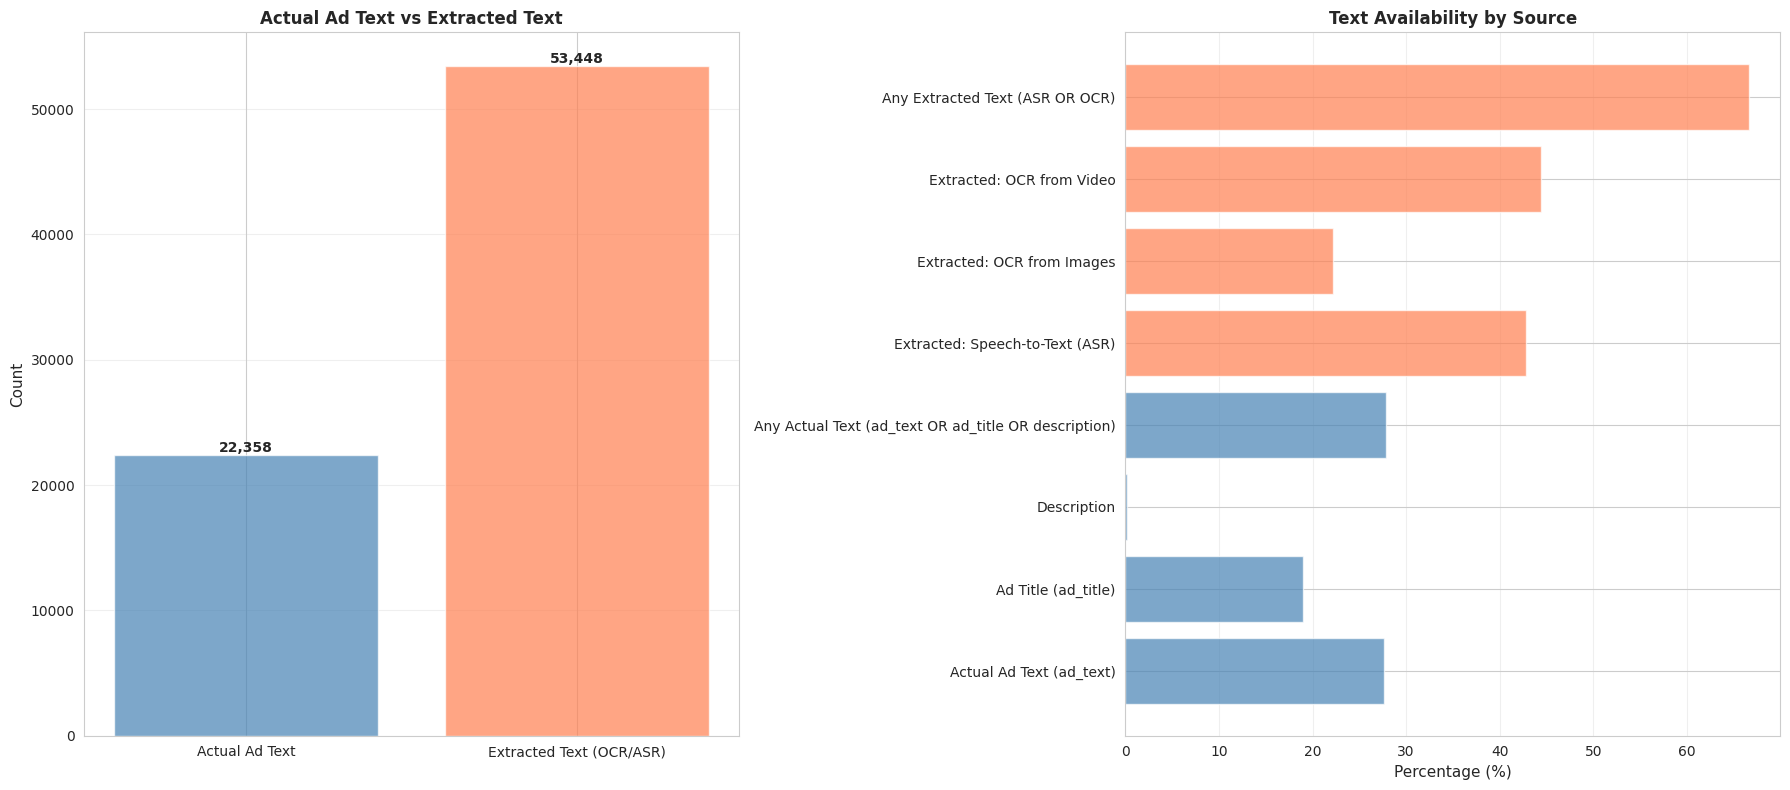


OVERLAP ANALYSIS
Ads with BOTH actual text AND extracted text: 6,536 (8.1%)
Ads with ONLY actual text (no extracted): 15,822 (19.7%)
Ads with ONLY extracted text (no actual): 46,912 (58.5%)
Ads with NEITHER: 10,977 (13.7%)


In [8]:
# COMPARISON: Actual Ad Text vs Extracted Text
print("=" * 80)
print("COMPARISON: ACTUAL AD TEXT vs EXTRACTED TEXT (OCR/ASR)")
print("=" * 80)

# Create comparison analysis
comparison_data = []

# Rows with actual ad text
has_ad_text = df['ad_text'].notna() & (df['ad_text'].astype(str).str.strip() != '')
has_ad_title = df['ad_title'].notna() & (df['ad_title'].astype(str).str.strip() != '')
has_description = df['description'].notna() & (df['description'].astype(str).str.strip() != '')

# Rows with extracted text
has_asr = df['google_asr_text'].notna() & (df['google_asr_text'].astype(str).str.strip() != '')
has_ocr_img = df['aws_ocr_img_text'].notna() & (df['aws_ocr_img_text'].astype(str).str.strip() != '')
has_ocr_vid = df['aws_ocr_video_text'].notna() & (df['aws_ocr_video_text'].astype(str).str.strip() != '')

# Actual ad text (any of: ad_text, ad_title, description)
has_actual_text = has_ad_text | has_ad_title | has_description

# Extracted text (any of: ASR, OCR)
has_extracted_text = has_asr | has_ocr_img | has_ocr_vid

comparison_data.append({
    'Category': 'Actual Ad Text (ad_text)',
    'Count': has_ad_text.sum(),
    'Percentage': (has_ad_text.sum() / len(df)) * 100
})
comparison_data.append({
    'Category': 'Ad Title (ad_title)',
    'Count': has_ad_title.sum(),
    'Percentage': (has_ad_title.sum() / len(df)) * 100
})
comparison_data.append({
    'Category': 'Description',
    'Count': has_description.sum(),
    'Percentage': (has_description.sum() / len(df)) * 100
})
comparison_data.append({
    'Category': 'Any Actual Text (ad_text OR ad_title OR description)',
    'Count': has_actual_text.sum(),
    'Percentage': (has_actual_text.sum() / len(df)) * 100
})
comparison_data.append({
    'Category': 'Extracted: Speech-to-Text (ASR)',
    'Count': has_asr.sum(),
    'Percentage': (has_asr.sum() / len(df)) * 100
})
comparison_data.append({
    'Category': 'Extracted: OCR from Images',
    'Count': has_ocr_img.sum(),
    'Percentage': (has_ocr_img.sum() / len(df)) * 100
})
comparison_data.append({
    'Category': 'Extracted: OCR from Video',
    'Count': has_ocr_vid.sum(),
    'Percentage': (has_ocr_vid.sum() / len(df)) * 100
})
comparison_data.append({
    'Category': 'Any Extracted Text (ASR OR OCR)',
    'Count': has_extracted_text.sum(),
    'Percentage': (has_extracted_text.sum() / len(df)) * 100
})

comparison_df = pd.DataFrame(comparison_data)
print("\nText Availability Comparison:")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Actual vs Extracted
actual_vs_extracted = pd.DataFrame({
    'Category': ['Actual Ad Text', 'Extracted Text (OCR/ASR)'],
    'Count': [has_actual_text.sum(), has_extracted_text.sum()],
    'Percentage': [(has_actual_text.sum() / len(df)) * 100, 
                    (has_extracted_text.sum() / len(df)) * 100]
})

axes[0].bar(actual_vs_extracted['Category'], actual_vs_extracted['Count'], 
            color=['steelblue', 'coral'], alpha=0.7)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Actual Ad Text vs Extracted Text', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(actual_vs_extracted['Count']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# All text sources
axes[1].barh(comparison_df['Category'], comparison_df['Percentage'], 
             color=['steelblue' if 'Actual' in cat or 'Title' in cat or 'Description' in cat else 'coral' 
                    for cat in comparison_df['Category']], alpha=0.7)
axes[1].set_xlabel('Percentage (%)', fontsize=11)
axes[1].set_title('Text Availability by Source', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Overlap analysis
both_actual_and_extracted = has_actual_text & has_extracted_text
only_actual = has_actual_text & ~has_extracted_text
only_extracted = has_extracted_text & ~has_actual_text
neither = ~has_actual_text & ~has_extracted_text

print("\n" + "=" * 80)
print("OVERLAP ANALYSIS")
print("=" * 80)
print(f"Ads with BOTH actual text AND extracted text: {both_actual_and_extracted.sum():,} ({both_actual_and_extracted.sum()/len(df)*100:.1f}%)")
print(f"Ads with ONLY actual text (no extracted): {only_actual.sum():,} ({only_actual.sum()/len(df)*100:.1f}%)")
print(f"Ads with ONLY extracted text (no actual): {only_extracted.sum():,} ({only_extracted.sum()/len(df)*100:.1f}%)")
print(f"Ads with NEITHER: {neither.sum():,} ({neither.sum()/len(df)*100:.1f}%)")


NLP USABILITY ASSESSMENT

NLP Usability Metrics:
--------------------------------------------------------------------------------
Total ads: 80,247
Ads with any text (>0 chars): 69,270 (86.3%)
Ads with substantial text (>50 chars): 66,545 (82.9%)
Ads with substantial text (>100 chars): 53,377 (66.5%)
Ads with substantial text (>200 chars): 38,294 (47.7%)

Text Length Statistics (for ads with text):
  Mean: 1039 characters
  Median: 348 characters
  Min: 3 characters
  Max: 62116 characters
  Std: 2137 characters


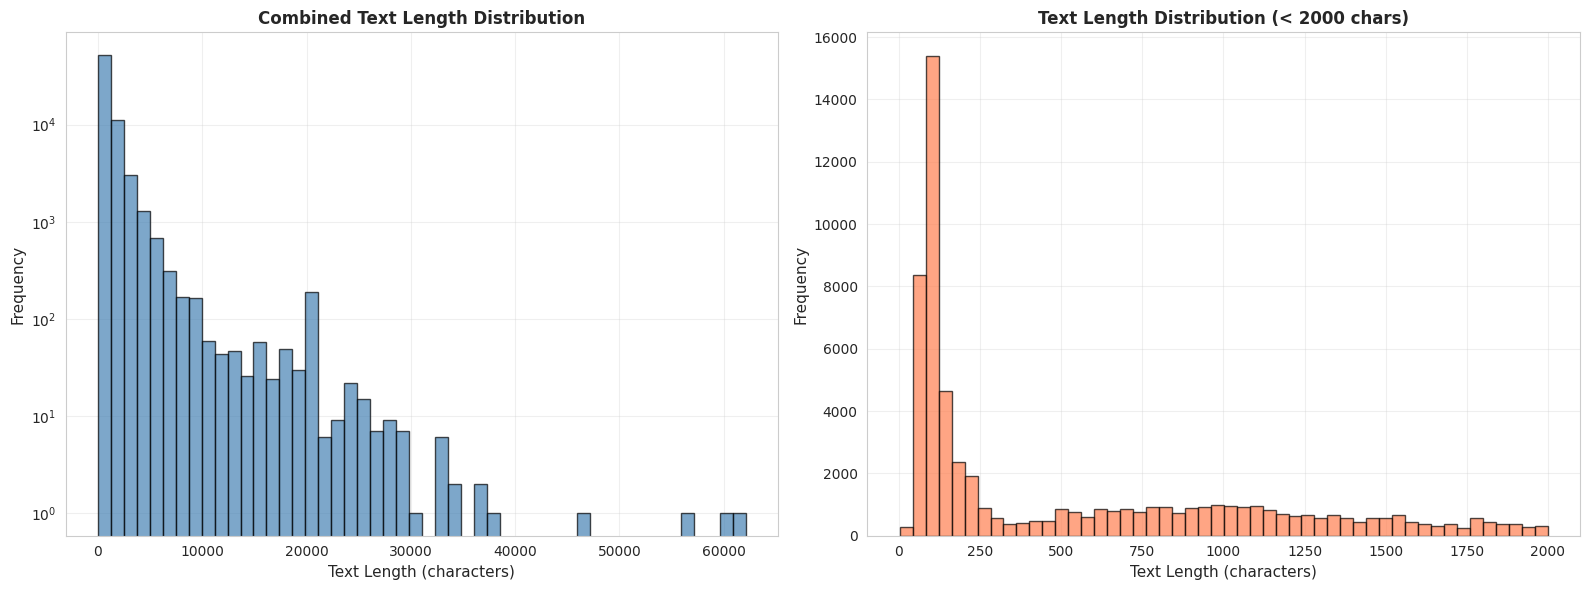


NLP USABILITY VERDICT

✅ HIGHLY USABLE
Reason: More than 50% of ads have substantial text (>100 chars)

Recommendation:
  - Dataset is suitable for NLP tasks
  - Can perform text classification, sentiment analysis, topic modeling
  - Consider filtering to ads with >100 chars for better quality


In [9]:
# NLP USABILITY ASSESSMENT
print("=" * 80)
print("NLP USABILITY ASSESSMENT")
print("=" * 80)

# Create combined text field for NLP analysis
def create_combined_text(row):
    """Combine all text sources, prioritizing actual ad text"""
    texts = []
    
    # Priority 1: Actual ad text
    if pd.notna(row.get('ad_text')) and str(row['ad_text']).strip() != '':
        texts.append(str(row['ad_text']).strip())
    
    # Priority 2: Ad title
    if pd.notna(row.get('ad_title')) and str(row['ad_title']).strip() != '':
        texts.append(str(row['ad_title']).strip())
    
    # Priority 3: Description
    if pd.notna(row.get('description')) and str(row['description']).strip() != '':
        texts.append(str(row['description']).strip())
    
    # Priority 4: Extracted text (if no actual text)
    if len(texts) == 0:
        if pd.notna(row.get('google_asr_text')) and str(row['google_asr_text']).strip() != '':
            texts.append(str(row['google_asr_text']).strip())
        if pd.notna(row.get('aws_ocr_img_text')) and str(row['aws_ocr_img_text']).strip() != '':
            texts.append(str(row['aws_ocr_img_text']).strip())
        if pd.notna(row.get('aws_ocr_video_text')) and str(row['aws_ocr_video_text']).strip() != '':
            texts.append(str(row['aws_ocr_video_text']).strip())
    
    return ' '.join(texts) if texts else ''

df['combined_text'] = df.apply(create_combined_text, axis=1)
df['combined_text_length'] = df['combined_text'].str.len()

# Usability metrics
print("\nNLP Usability Metrics:")
print("-" * 80)

total_ads = len(df)
ads_with_text = (df['combined_text_length'] > 0).sum()
ads_with_substantial_text_50 = (df['combined_text_length'] > 50).sum()
ads_with_substantial_text_100 = (df['combined_text_length'] > 100).sum()
ads_with_substantial_text_200 = (df['combined_text_length'] > 200).sum()

print(f"Total ads: {total_ads:,}")
print(f"Ads with any text (>0 chars): {ads_with_text:,} ({ads_with_text/total_ads*100:.1f}%)")
print(f"Ads with substantial text (>50 chars): {ads_with_substantial_text_50:,} ({ads_with_substantial_text_50/total_ads*100:.1f}%)")
print(f"Ads with substantial text (>100 chars): {ads_with_substantial_text_100:,} ({ads_with_substantial_text_100/total_ads*100:.1f}%)")
print(f"Ads with substantial text (>200 chars): {ads_with_substantial_text_200:,} ({ads_with_substantial_text_200/total_ads*100:.1f}%)")

# Text length distribution
non_zero_text = df[df['combined_text_length'] > 0]['combined_text_length']
print(f"\nText Length Statistics (for ads with text):")
print(f"  Mean: {non_zero_text.mean():.0f} characters")
print(f"  Median: {non_zero_text.median():.0f} characters")
print(f"  Min: {non_zero_text.min():.0f} characters")
print(f"  Max: {non_zero_text.max():.0f} characters")
print(f"  Std: {non_zero_text.std():.0f} characters")

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(non_zero_text, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Text Length (characters)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Combined Text Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Focus on shorter texts
axes[1].hist(non_zero_text[non_zero_text < 2000], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Text Length (characters)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Text Length Distribution (< 2000 chars)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Usability assessment
print("\n" + "=" * 80)
print("NLP USABILITY VERDICT")
print("=" * 80)

if ads_with_substantial_text_100 / total_ads > 0.5:
    verdict = "✅ HIGHLY USABLE"
    reason = f"More than 50% of ads have substantial text (>100 chars)"
elif ads_with_substantial_text_50 / total_ads > 0.5:
    verdict = "✅ USABLE"
    reason = f"More than 50% of ads have text (>50 chars), though many are short"
elif ads_with_text / total_ads > 0.5:
    verdict = "⚠️  PARTIALLY USABLE"
    reason = f"More than 50% of ads have some text, but many are very short"
else:
    verdict = "❌ LIMITED USABILITY"
    reason = f"Less than 50% of ads have text content"

print(f"\n{verdict}")
print(f"Reason: {reason}")
print(f"\nRecommendation:")
if ads_with_substantial_text_100 / total_ads > 0.3:
    print("  - Dataset is suitable for NLP tasks")
    print("  - Can perform text classification, sentiment analysis, topic modeling")
    print("  - Consider filtering to ads with >100 chars for better quality")
elif ads_with_text / total_ads > 0.3:
    print("  - Dataset can be used for NLP but with limitations")
    print("  - Many ads have short text - may need to combine with metadata")
    print("  - Consider using extracted text (OCR/ASR) to supplement actual text")
else:
    print("  - Dataset has limited text content")
    print("  - May need to rely more on metadata features")
    print("  - Consider supplementing with extracted text sources")


In [ ]:
# AD TYPE ANALYSIS
print("=" * 80)
print("AD TYPE ANALYSIS")
print("=" * 80)

if 'ad_type' in df.columns:
    ad_type_counts = df['ad_type'].value_counts()
    print("\nAd Type Distribution:")
    print(ad_type_counts)
    print(f"\nMissing ad_type: {df['ad_type'].isna().sum():,}")
    
    # Analyze text availability by ad type
    print("\n" + "=" * 80)
    print("TEXT AVAILABILITY BY AD TYPE")
    print("=" * 80)
    
    ad_type_text_analysis = []
    for ad_type in df['ad_type'].dropna().unique():
        type_df = df[df['ad_type'] == ad_type]
        has_text = (type_df['combined_text_length'] > 0).sum()
        has_substantial = (type_df['combined_text_length'] > 100).sum()
        
        ad_type_text_analysis.append({
            'Ad_Type': ad_type,
            'Total_Ads': len(type_df),
            'Has_Text': has_text,
            'Has_Text_Pct': (has_text / len(type_df)) * 100,
            'Has_Substantial_Text': has_substantial,
            'Has_Substantial_Text_Pct': (has_substantial / len(type_df)) * 100,
            'Mean_Text_Length': type_df[type_df['combined_text_length'] > 0]['combined_text_length'].mean()
        })
    
    ad_type_text_df = pd.DataFrame(ad_type_text_analysis)
    ad_type_text_df = ad_type_text_df.sort_values('Total_Ads', ascending=False)
    print(ad_type_text_df.to_string(index=False))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].bar(ad_type_counts.index, ad_type_counts.values, color='steelblue', alpha=0.7)
    axes[0].set_xlabel('Ad Type', fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].set_title('Ad Type Distribution', fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    axes[1].barh(ad_type_text_df['Ad_Type'], ad_type_text_df['Has_Substantial_Text_Pct'], 
                 color='coral', alpha=0.7)
    axes[1].set_xlabel('Percentage with Substantial Text (>100 chars)', fontsize=11)
    axes[1].set_title('Text Availability by Ad Type', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()


In [10]:
# SAMPLE TEXT ANALYSIS - Show examples of different text sources
print("=" * 80)
print("SAMPLE TEXT ANALYSIS - Examples by Text Source")
print("=" * 80)

# Sample ads with different text sources
samples = {
    'Has ad_text only': df[df['ad_text'].notna() & (df['ad_text'].astype(str).str.strip() != '') & 
                           df['google_asr_text'].isna() & df['aws_ocr_img_text'].isna()].head(3),
    'Has ASR text (video)': df[df['google_asr_text'].notna() & 
                                (df['google_asr_text'].astype(str).str.strip() != '')].head(3),
    'Has OCR image text': df[df['aws_ocr_img_text'].notna() & 
                             (df['aws_ocr_img_text'].astype(str).str.strip() != '')].head(3),
    'Has OCR video text': df[df['aws_ocr_video_text'].notna() & 
                             (df['aws_ocr_video_text'].astype(str).str.strip() != '')].head(3),
    'Has both actual and extracted': df[(df['ad_text'].notna() & (df['ad_text'].astype(str).str.strip() != '')) &
                                         ((df['google_asr_text'].notna() & (df['google_asr_text'].astype(str).str.strip() != '')) |
                                          (df['aws_ocr_img_text'].notna() & (df['aws_ocr_img_text'].astype(str).str.strip() != '')))].head(3)
}

for category, sample_df in samples.items():
    if len(sample_df) > 0:
        print(f"\n{'='*100}")
        print(f"CATEGORY: {category}")
        print(f"{'='*100}")
        
        for idx, (row_idx, row) in enumerate(sample_df.iterrows(), 1):
            print(f"\n--- Example {idx} ---")
            print(f"Ad ID: {row.get('ad_id', 'N/A')}")
            print(f"Advertiser: {row.get('advertiser_name', 'N/A')}")
            print(f"Ad Type: {row.get('ad_type', 'N/A')}")
            
            if pd.notna(row.get('ad_text')) and str(row['ad_text']).strip() != '':
                print(f"\n📝 ad_text: {str(row['ad_text'])[:500]}")
            
            if pd.notna(row.get('ad_title')) and str(row['ad_title']).strip() != '':
                print(f"\n📌 ad_title: {row['ad_title']}")
            
            if pd.notna(row.get('google_asr_text')) and str(row['google_asr_text']).strip() != '':
                asr = str(row['google_asr_text'])
                print(f"\n🎥 google_asr_text (first 500 chars): {asr[:500]}")
            
            if pd.notna(row.get('aws_ocr_img_text')) and str(row['aws_ocr_img_text']).strip() != '':
                ocr_img = str(row['aws_ocr_img_text'])
                print(f"\n🖼️  aws_ocr_img_text (first 500 chars): {ocr_img[:500]}")
            
            if pd.notna(row.get('aws_ocr_video_text')) and str(row['aws_ocr_video_text']).strip() != '':
                ocr_vid = str(row['aws_ocr_video_text'])
                print(f"\n🎬 aws_ocr_video_text (first 500 chars): {ocr_vid[:500]}")
            
            print("\n" + "-"*100)


SAMPLE TEXT ANALYSIS - Examples by Text Source

CATEGORY: Has ad_text only

--- Example 1 ---
Ad ID: CR00000354386341527553
Advertiser: PROGRESSNOW COLORADO
Ad Type: TEXT

📝 ad_text: Learn About Colorado Proposition GG Concerning Tax Transparency On Ballot Initiatives

📌 ad_title: Colorado Proposition GG

----------------------------------------------------------------------------------------------------

--- Example 2 ---
Ad ID: CR00002421743079653377
Advertiser: MD Rahman for Senate
Ad Type: TEXT

📝 ad_text: MD Rahman is on your side.

📌 ad_title: MD Rahman

----------------------------------------------------------------------------------------------------

--- Example 3 ---
Ad ID: CR00002464624033136641
Advertiser: PROGRESS MICHIGAN POLITICAL ACTION FUND (SUPERPAC)
Ad Type: TEXT

📝 ad_text: Learn About All Five Candidates Running for Michigan Supreme Court This Year

📌 ad_title: Facts About Kyra Harris Bolden

------------------------------------------------------------------------

BASIC NLP FEATURES - Text Quality Assessment
Extracting NLP features for 10,000 ads with text...

NLP Features Statistics:
         word_count  sentence_count  has_punctuation  has_capitalization  \
count  10000.000000    10000.000000     10000.000000        10000.000000   
mean     173.951800        8.507600         0.805100            0.999500   
std      368.718268       21.486342         0.396144            0.022356   
min        1.000000        1.000000         0.000000            0.000000   
25%       17.000000        1.000000         1.000000            1.000000   
50%       60.000000        4.000000         1.000000            1.000000   
75%      207.000000       11.000000         1.000000            1.000000   
max     7209.000000      841.000000         1.000000            1.000000   

       has_numbers  avg_word_length  
count      10000.0     10000.000000  
mean           0.0         5.133097  
std            0.0         0.597471  
min            0.0         1.000000  
25

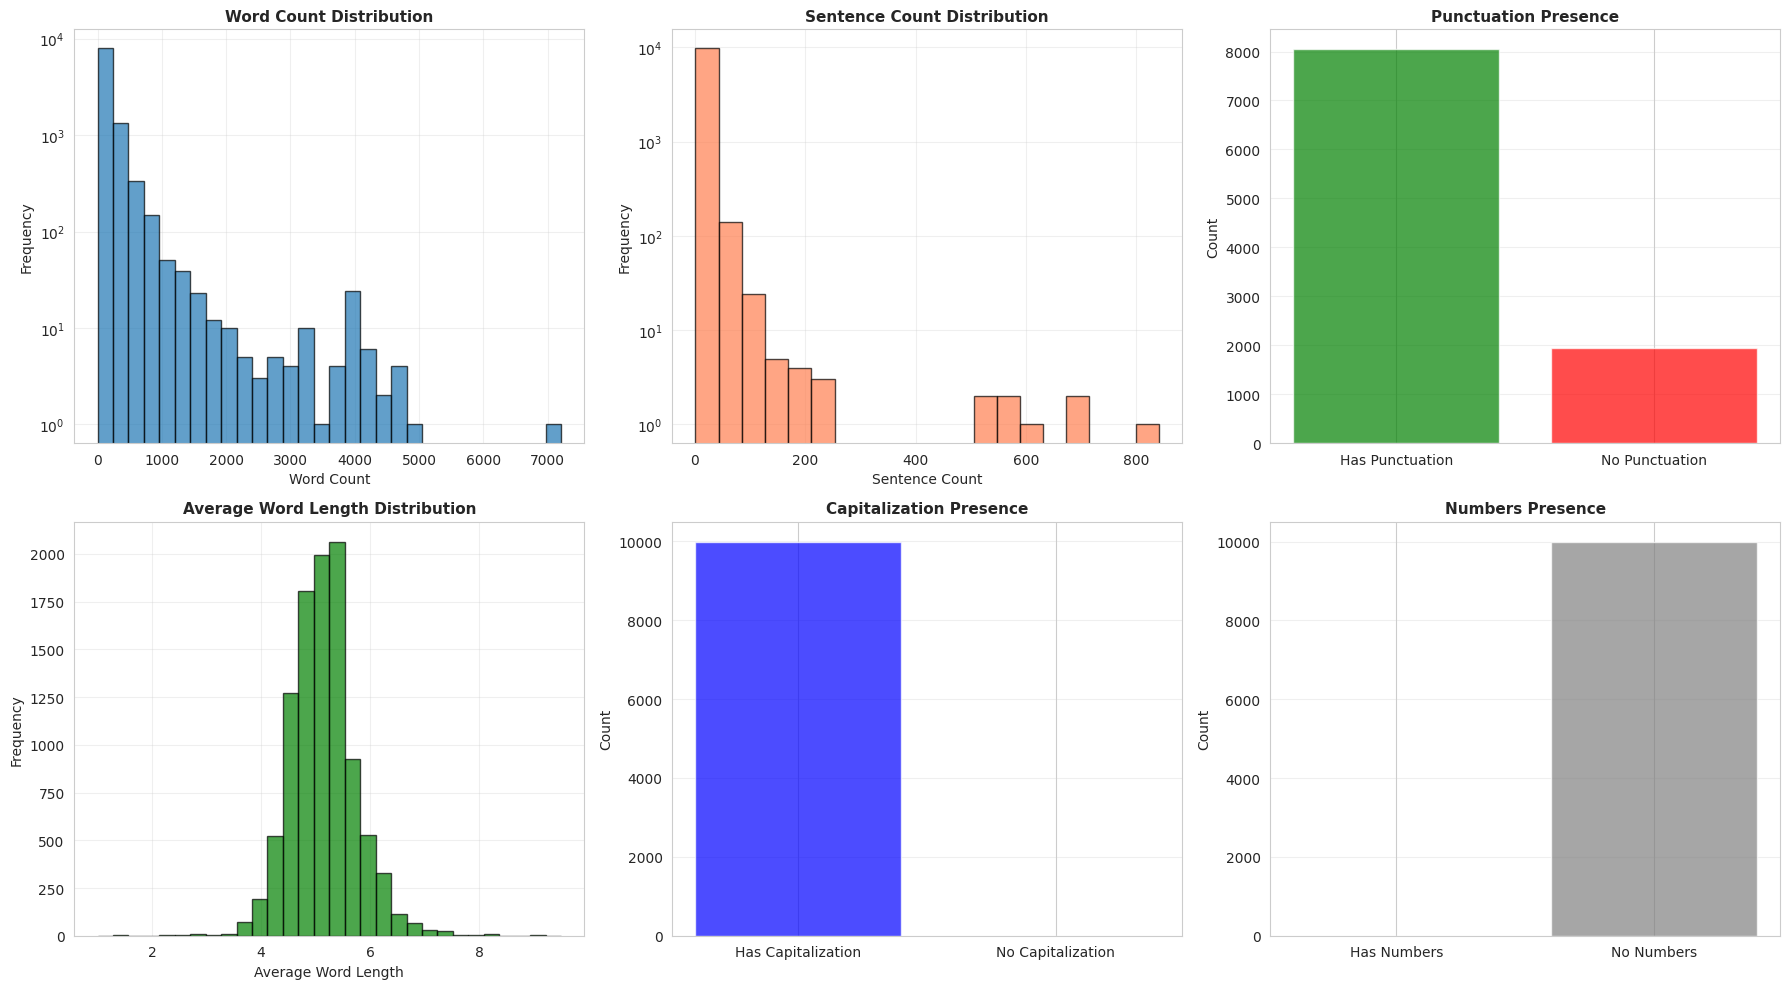

In [11]:
# BASIC NLP FEATURES EXTRACTION (to assess quality)
print("=" * 80)
print("BASIC NLP FEATURES - Text Quality Assessment")
print("=" * 80)

def extract_basic_nlp_features(text):
    """Extract basic features to assess text quality"""
    if pd.isna(text) or str(text).strip() == '':
        return {
            'word_count': 0,
            'sentence_count': 0,
            'has_punctuation': 0,
            'has_capitalization': 0,
            'has_numbers': 0,
            'avg_word_length': 0
        }
    
    text_str = str(text)
    words = text_str.split()
    sentences = re.split(r'[.!?]+', text_str)
    
    return {
        'word_count': len(words),
        'sentence_count': len([s for s in sentences if s.strip()]),
        'has_punctuation': 1 if re.search(r'[.!?,;:]+', text_str) else 0,
        'has_capitalization': 1 if re.search(r'[A-Z]', text_str) else 0,
        'has_numbers': 1 if re.search(r'\\d', text_str) else 0,
        'avg_word_length': np.mean([len(w) for w in words]) if words else 0
    }

# Sample for performance
sample_size = min(10000, len(df[df['combined_text_length'] > 0]))
sample_df = df[df['combined_text_length'] > 0].head(sample_size).copy()

print(f"Extracting NLP features for {len(sample_df):,} ads with text...")
nlp_features = sample_df['combined_text'].apply(extract_basic_nlp_features)
nlp_df = pd.DataFrame(list(nlp_features))

print("\nNLP Features Statistics:")
print(nlp_df.describe())

# Assess text quality
print("\n" + "=" * 80)
print("TEXT QUALITY ASSESSMENT")
print("=" * 80)

quality_metrics = {
    'Has punctuation': (nlp_df['has_punctuation'] == 1).sum(),
    'Has capitalization': (nlp_df['has_capitalization'] == 1).sum(),
    'Has numbers': (nlp_df['has_numbers'] == 1).sum(),
    'Word count > 10': (nlp_df['word_count'] > 10).sum(),
    'Word count > 20': (nlp_df['word_count'] > 20).sum(),
    'Sentence count > 1': (nlp_df['sentence_count'] > 1).sum()
}

print("\nQuality Metrics (for sample):")
for metric, count in quality_metrics.items():
    pct = (count / len(nlp_df)) * 100
    print(f"  {metric:25s}: {count:6,} ({pct:5.1f}%)")

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(nlp_df['word_count'][nlp_df['word_count'] > 0], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Word Count', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Word Count Distribution', fontsize=11, fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(nlp_df['sentence_count'][nlp_df['sentence_count'] > 0], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Sentence Count', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Sentence Count Distribution', fontsize=11, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].bar(['Has Punctuation', 'No Punctuation'], 
               [(nlp_df['has_punctuation'] == 1).sum(), (nlp_df['has_punctuation'] == 0).sum()],
               color=['green', 'red'], alpha=0.7)
axes[0, 2].set_ylabel('Count', fontsize=10)
axes[0, 2].set_title('Punctuation Presence', fontsize=11, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='y')

axes[1, 0].hist(nlp_df['avg_word_length'][nlp_df['avg_word_length'] > 0], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Average Word Length', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Average Word Length Distribution', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].bar(['Has Capitalization', 'No Capitalization'],
               [(nlp_df['has_capitalization'] == 1).sum(), (nlp_df['has_capitalization'] == 0).sum()],
               color=['blue', 'orange'], alpha=0.7)
axes[1, 1].set_ylabel('Count', fontsize=10)
axes[1, 1].set_title('Capitalization Presence', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

axes[1, 2].bar(['Has Numbers', 'No Numbers'],
               [(nlp_df['has_numbers'] == 1).sum(), (nlp_df['has_numbers'] == 0).sum()],
               color=['purple', 'gray'], alpha=0.7)
axes[1, 2].set_ylabel('Count', fontsize=10)
axes[1, 2].set_title('Numbers Presence', fontsize=11, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


ADVERTISER ANALYSIS

Total unique advertisers: 2,901

Top 20 advertisers by ad count:
advertiser_name
KEVIN COMBS                                           13914
PROGRESSNOW COLORADO                                   2629
Arora For CT                                           2625
PROGRESS MICHIGAN POLITICAL ACTION FUND (SUPERPAC)     1699
DFL HOUSE CAUCUS                                       1530
Congressional Leadership Fund                          1054
CATHERINE CORTEZ MASTO FOR SENATE                      1008
DCCC                                                    982
ProgressNow                                             880
WAY TO WIN ACTION FUND                                  804
Money Metals Exchange LLC                               793
ALLIANCE FOR A BETTER MINNESOTA ACTION FUND             790
HOUSE MAJORITY PAC                                      681
Mary Peltola for Alaska                                 638
THE VOTER PARTICIPATION CENTER                          56

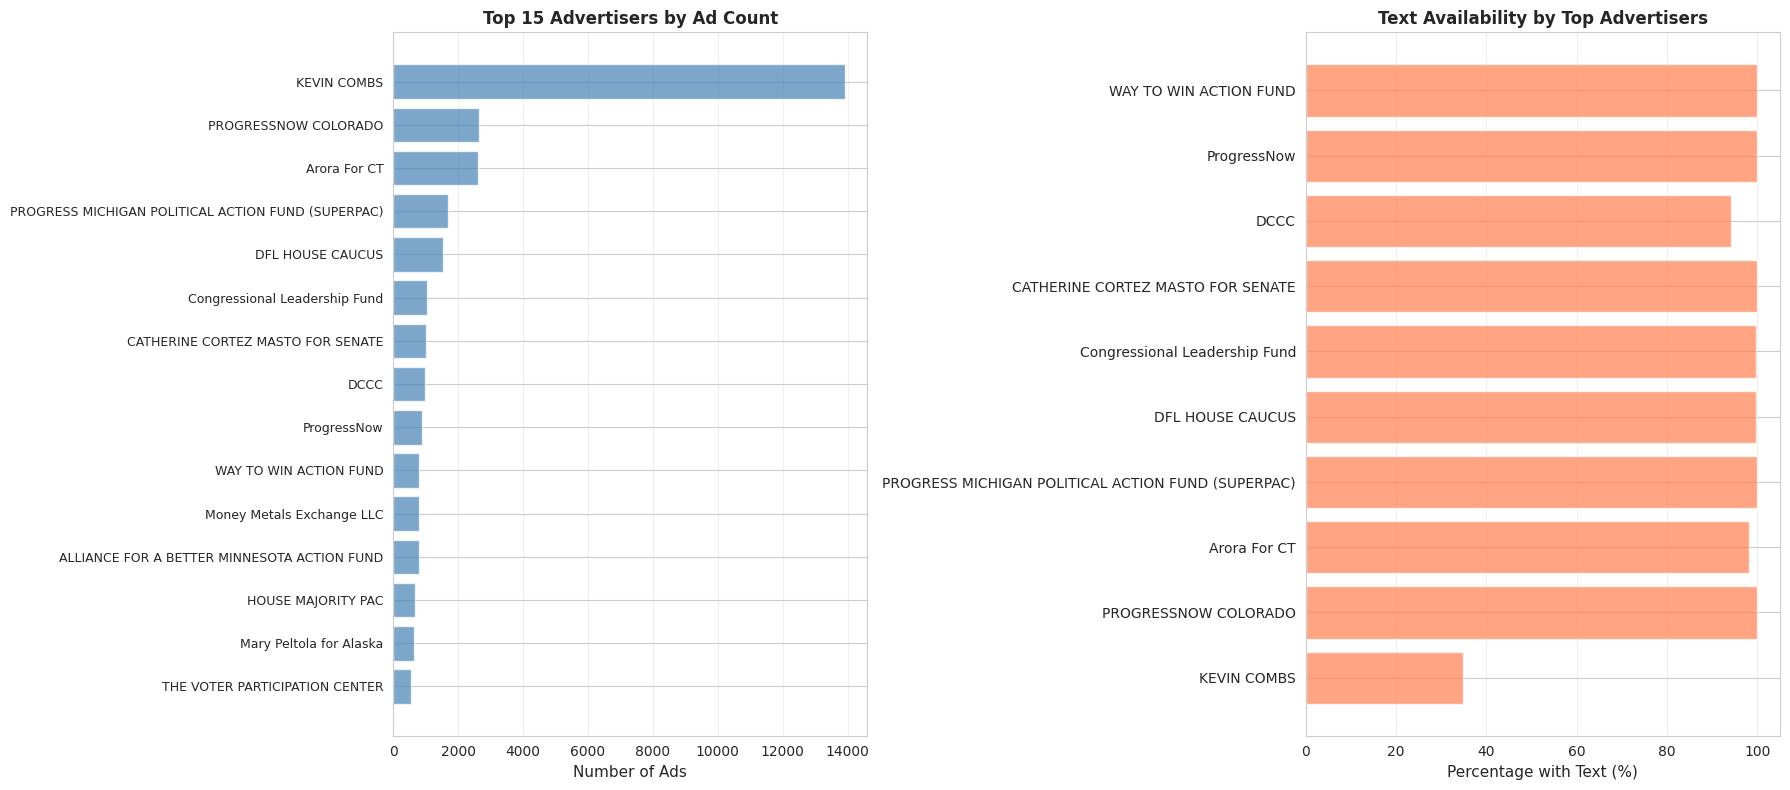

In [12]:
# ADVERTISER ANALYSIS
print("=" * 80)
print("ADVERTISER ANALYSIS")
print("=" * 80)

if 'advertiser_name' in df.columns:
    advertiser_counts = df['advertiser_name'].value_counts()
    print(f"\nTotal unique advertisers: {df['advertiser_name'].nunique():,}")
    print(f"\nTop 20 advertisers by ad count:")
    print(advertiser_counts.head(20))
    
    # Analyze text availability by advertiser (top 10)
    print("\n" + "=" * 80)
    print("TEXT AVAILABILITY BY TOP ADVERTISERS")
    print("=" * 80)
    
    top_advertisers = advertiser_counts.head(10).index
    advertiser_text_analysis = []
    
    for advertiser in top_advertisers:
        adv_df = df[df['advertiser_name'] == advertiser]
        has_text = (adv_df['combined_text_length'] > 0).sum()
        has_substantial = (adv_df['combined_text_length'] > 100).sum()
        
        advertiser_text_analysis.append({
            'Advertiser': advertiser,
            'Total_Ads': len(adv_df),
            'Has_Text': has_text,
            'Has_Text_Pct': (has_text / len(adv_df)) * 100,
            'Has_Substantial_Text': has_substantial,
            'Mean_Text_Length': adv_df[adv_df['combined_text_length'] > 0]['combined_text_length'].mean()
        })
    
    adv_text_df = pd.DataFrame(advertiser_text_analysis)
    print(adv_text_df.to_string(index=False))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    axes[0].barh(range(len(advertiser_counts.head(15))), advertiser_counts.head(15).values, 
                 color='steelblue', alpha=0.7)
    axes[0].set_yticks(range(len(advertiser_counts.head(15))))
    axes[0].set_yticklabels(advertiser_counts.head(15).index, fontsize=9)
    axes[0].set_xlabel('Number of Ads', fontsize=11)
    axes[0].set_title('Top 15 Advertisers by Ad Count', fontsize=12, fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3, axis='x')
    
    axes[1].barh(adv_text_df['Advertiser'], adv_text_df['Has_Text_Pct'], 
                 color='coral', alpha=0.7)
    axes[1].set_xlabel('Percentage with Text (%)', fontsize=11)
    axes[1].set_title('Text Availability by Top Advertisers', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()


AD TYPE FILTERING - LONGEST ADS WITH EXTRACTED TEXT

Ad Type Distribution:
ad_type
VIDEO    36271
IMAGE    28153
TEXT     15823
Name: count, dtype: int64

AD TYPE: VIDEO

⚠️  No ads of type 'VIDEO' with ad_text found

AD TYPE: TEXT

Total ads of type 'TEXT': 15,823
Ads with ad_text: 15,030

Showing top 10 longest ad_text ads:

#1 - LONGEST AD_TEXT (Length: 357 characters)
Ad ID: CR00374561898860904449
Advertiser: DISPATCH MEDIA INC
Ad Type: TEXT
Ad URL: https://adstransparency.google.com/advertiser/AR18409007391535267841/creative/CR00374561898860904449?political=&region=US

📝 ACTUAL AD TEXT (ad_text) - FULL TEXT:
----------------------------------------------------------------------------------------------------
Get news & analysis from a conservative perspective: Subscribe to our fact-based reporting Join tens of thousands of subscribers and stay informed with our trustworthy commentary. Member focused. Podcasts. Types: Member-only Newsletters, Member-only Commenting, Member Livestrea

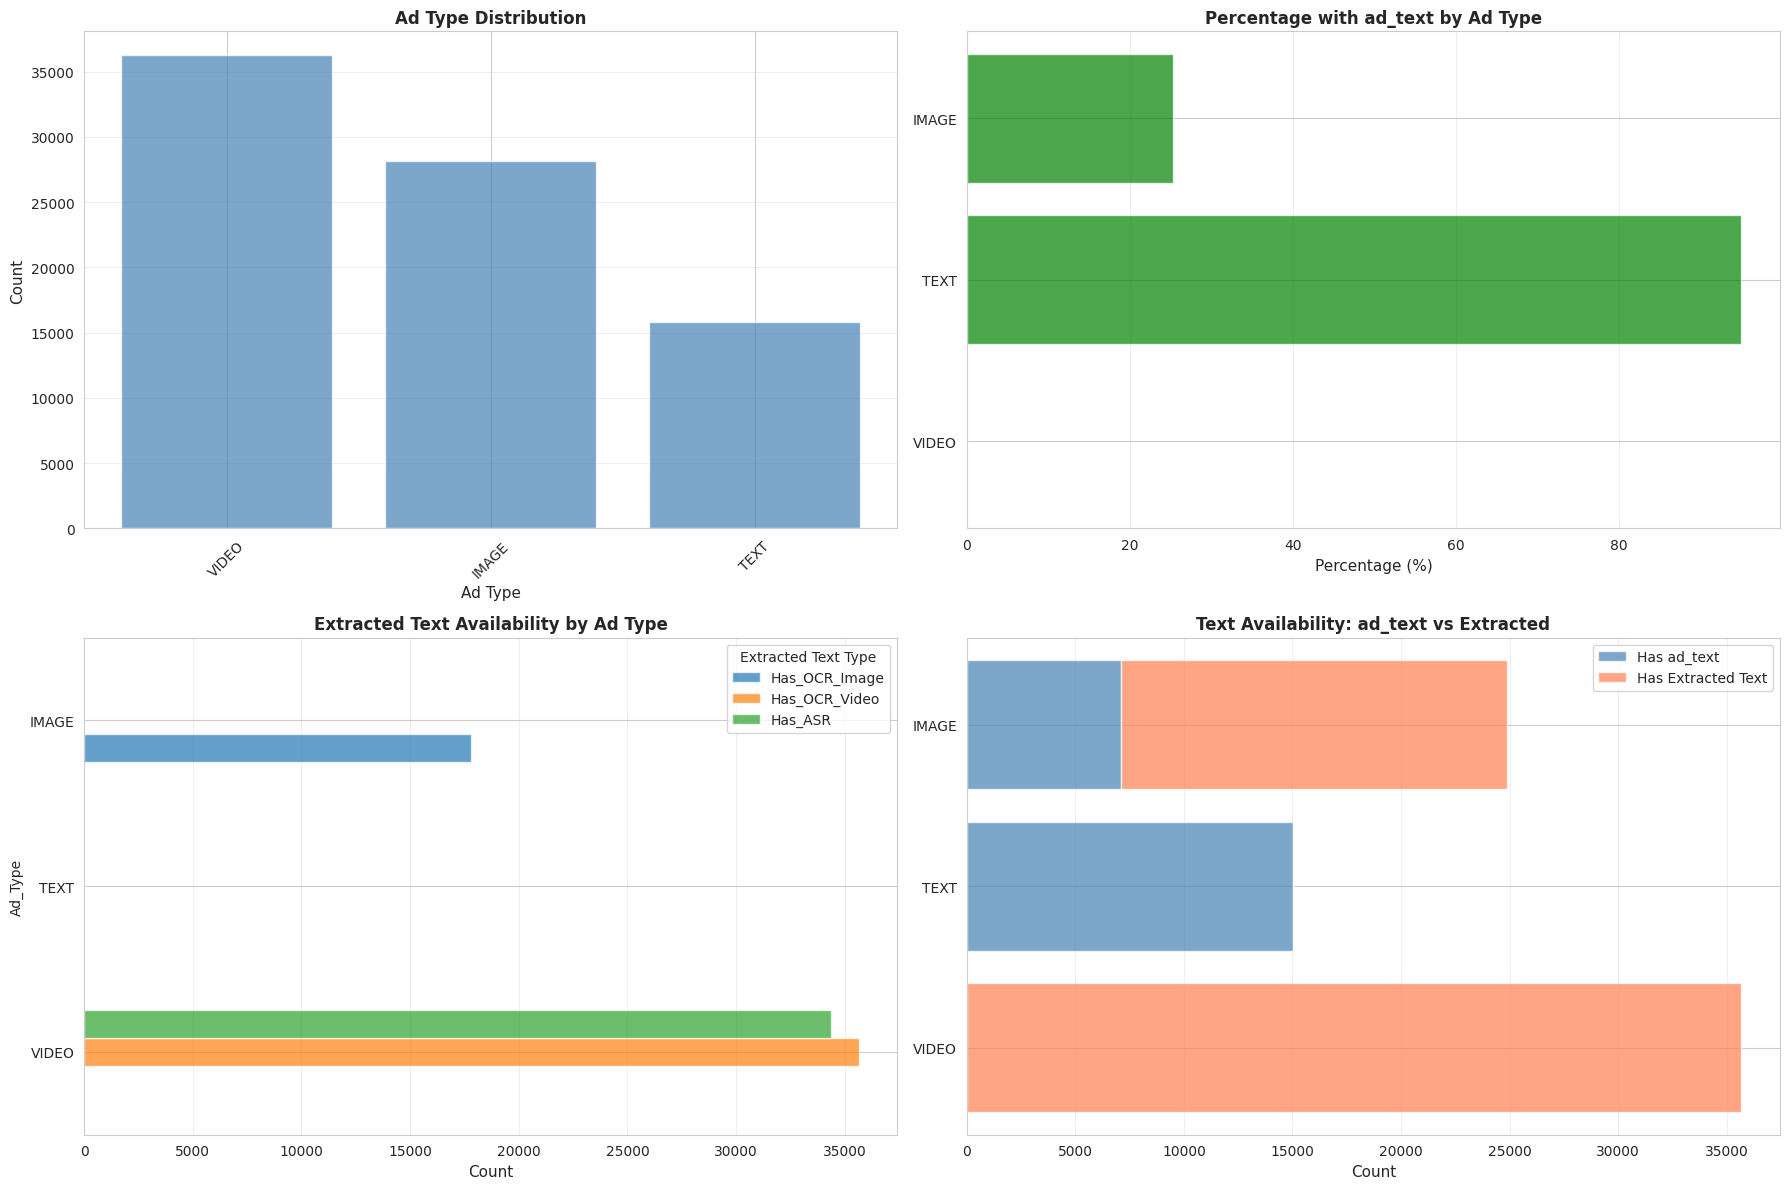

In [13]:
# FILTER BY AD TYPE AND SHOW LONGEST ADS WITH EXTRACTED TEXT
print("=" * 80)
print("AD TYPE FILTERING - LONGEST ADS WITH EXTRACTED TEXT")
print("=" * 80)

if 'ad_type' in df.columns:
    # Show ad type distribution
    print("\nAd Type Distribution:")
    ad_type_counts = df['ad_type'].value_counts()
    print(ad_type_counts)
    
    # Filter for each ad type and find longest ads
    ad_types = df['ad_type'].dropna().unique()
    
    for ad_type in ad_types:
        print("\n" + "=" * 100)
        print(f"AD TYPE: {ad_type}")
        print("=" * 100)
        
        # Filter by ad type
        type_df = df[df['ad_type'] == ad_type].copy()
        
        # Filter to ads that have ad_text
        type_df_with_text = type_df[type_df['ad_text'].notna() & 
                                     (type_df['ad_text'].astype(str).str.strip() != '')].copy()
        
        if len(type_df_with_text) > 0:
            # Calculate ad_text length
            type_df_with_text['ad_text_length'] = type_df_with_text['ad_text'].astype(str).str.len()
            
            # Get top 10 longest ad_text
            top_10_longest = type_df_with_text.nlargest(10, 'ad_text_length')
            
            print(f"\nTotal ads of type '{ad_type}': {len(type_df):,}")
            print(f"Ads with ad_text: {len(type_df_with_text):,}")
            print(f"\nShowing top 10 longest ad_text ads:\n")
            
            for idx, (row_idx, row) in enumerate(top_10_longest.iterrows(), 1):
                print("=" * 100)
                print(f"#{idx} - LONGEST AD_TEXT (Length: {row['ad_text_length']} characters)")
                print("=" * 100)
                print(f"Ad ID: {row.get('ad_id', 'N/A')}")
                print(f"Advertiser: {row.get('advertiser_name', 'N/A')}")
                print(f"Ad Type: {row.get('ad_type', 'N/A')}")
                print(f"Ad URL: {row.get('ad_url', 'N/A')}")
                
                # Show the actual ad_text (full text)
                if pd.notna(row.get('ad_text')) and str(row['ad_text']).strip() != '':
                    print(f"\n📝 ACTUAL AD TEXT (ad_text) - FULL TEXT:")
                    print("-" * 100)
                    print(str(row['ad_text']))
                    print(f"Length: {row['ad_text_length']} characters")
                
                # Check for extracted text
                has_extracted = False
                
                # Check for OCR image text
                if pd.notna(row.get('aws_ocr_img_text')) and str(row['aws_ocr_img_text']).strip() != '':
                    has_extracted = True
                    ocr_img = str(row['aws_ocr_img_text'])
                    print(f"\n🖼️  EXTRACTED TEXT FROM IMAGES (aws_ocr_img_text):")
                    print("-" * 100)
                    print(ocr_img[:2000] + ('...' if len(ocr_img) > 2000 else ''))
                    print(f"Length: {len(ocr_img)} characters")
                
                # Check for OCR video text
                if pd.notna(row.get('aws_ocr_video_text')) and str(row['aws_ocr_video_text']).strip() != '':
                    has_extracted = True
                    ocr_vid = str(row['aws_ocr_video_text'])
                    print(f"\n🎬 EXTRACTED TEXT FROM VIDEO FRAMES (aws_ocr_video_text):")
                    print("-" * 100)
                    print(ocr_vid[:2000] + ('...' if len(ocr_vid) > 2000 else ''))
                    print(f"Length: {len(ocr_vid)} characters")
                
                # Check for ASR text (speech-to-text)
                if pd.notna(row.get('google_asr_text')) and str(row['google_asr_text']).strip() != '':
                    has_extracted = True
                    asr_text = str(row['google_asr_text'])
                    print(f"\n🎥 EXTRACTED TEXT FROM VIDEO AUDIO (google_asr_text - Speech-to-Text):")
                    print("-" * 100)
                    print(asr_text[:2000] + ('...' if len(asr_text) > 2000 else ''))
                    print(f"Length: {len(asr_text)} characters")
                
                if not has_extracted:
                    print(f"\n⚠️  No extracted text (OCR/ASR) available for this ad")
                
                # Show ad_title and description if available
                if pd.notna(row.get('ad_title')) and str(row['ad_title']).strip() != '':
                    print(f"\n📌 AD TITLE: {row['ad_title']}")
                
                if pd.notna(row.get('description')) and str(row['description']).strip() != '':
                    print(f"\n📄 DESCRIPTION: {str(row['description'])[:500]}")
                
                print("\n")
        else:
            print(f"\n⚠️  No ads of type '{ad_type}' with ad_text found")
    
    # Summary by ad type
    print("\n" + "=" * 100)
    print("SUMMARY: TEXT AVAILABILITY BY AD TYPE")
    print("=" * 100)
    
    summary_data = []
    for ad_type in ad_types:
        type_df = df[df['ad_type'] == ad_type]
        has_ad_text = type_df['ad_text'].notna() & (type_df['ad_text'].astype(str).str.strip() != '')
        has_ocr_img = type_df['aws_ocr_img_text'].notna() & (type_df['aws_ocr_img_text'].astype(str).str.strip() != '')
        has_ocr_vid = type_df['aws_ocr_video_text'].notna() & (type_df['aws_ocr_video_text'].astype(str).str.strip() != '')
        has_asr = type_df['google_asr_text'].notna() & (type_df['google_asr_text'].astype(str).str.strip() != '')
        
        summary_data.append({
            'Ad_Type': ad_type,
            'Total_Ads': len(type_df),
            'Has_ad_text': has_ad_text.sum(),
            'Has_ad_text_Pct': (has_ad_text.sum() / len(type_df)) * 100,
            'Has_OCR_Image': has_ocr_img.sum(),
            'Has_OCR_Video': has_ocr_vid.sum(),
            'Has_ASR': has_asr.sum(),
            'Has_Any_Extracted': (has_ocr_img | has_ocr_vid | has_asr).sum()
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Ad type distribution
    axes[0, 0].bar(ad_type_counts.index, ad_type_counts.values, color='steelblue', alpha=0.7)
    axes[0, 0].set_xlabel('Ad Type', fontsize=11)
    axes[0, 0].set_ylabel('Count', fontsize=11)
    axes[0, 0].set_title('Ad Type Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Has ad_text percentage
    axes[0, 1].barh(summary_df['Ad_Type'], summary_df['Has_ad_text_Pct'], color='green', alpha=0.7)
    axes[0, 1].set_xlabel('Percentage (%)', fontsize=11)
    axes[0, 1].set_title('Percentage with ad_text by Ad Type', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # Extracted text availability
    extracted_data = summary_df[['Ad_Type', 'Has_OCR_Image', 'Has_OCR_Video', 'Has_ASR']].set_index('Ad_Type')
    extracted_data.plot(kind='barh', ax=axes[1, 0], alpha=0.7)
    axes[1, 0].set_xlabel('Count', fontsize=11)
    axes[1, 0].set_title('Extracted Text Availability by Ad Type', fontsize=12, fontweight='bold')
    axes[1, 0].legend(title='Extracted Text Type')
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # Combined view
    axes[1, 1].barh(summary_df['Ad_Type'], summary_df['Has_ad_text'], label='Has ad_text', color='steelblue', alpha=0.7)
    axes[1, 1].barh(summary_df['Ad_Type'], summary_df['Has_Any_Extracted'], 
                    left=summary_df['Has_ad_text'], label='Has Extracted Text', color='coral', alpha=0.7)
    axes[1, 1].set_xlabel('Count', fontsize=11)
    axes[1, 1].set_title('Text Availability: ad_text vs Extracted', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️  'ad_type' column not found in dataset")


TEXT LENGTH DISTRIBUTION BY MEDIA TYPE (AD_TYPE)
Combining all text sources: ad_text, description, google_asr_text, aws_ocr_img_text, aws_ocr_video_text

Ad Types found: ['VIDEO', 'TEXT', 'IMAGE']

Analyzing text length distribution for each ad type...

TEXT LENGTH STATISTICS BY AD TYPE
Ad_Type  Total_Ads  Ads_With_Text  Ads_With_Text_Pct  Mean_Length  Median_Length  Min_Length  Max_Length  Std_Length   Q25    Q75    Q90    Q95
  VIDEO      36271          35670          98.343029  1923.962994         1218.0          14       62116 2716.708663 810.0 1955.0 3541.0 5258.1
  IMAGE      28153          18570          65.960999   138.894723          123.0           3         833   78.270792  80.0  171.0  229.0  271.0
   TEXT      15823          15030          94.988308    79.008782           76.0           9         357   28.671968  65.0   87.0   90.0  152.0


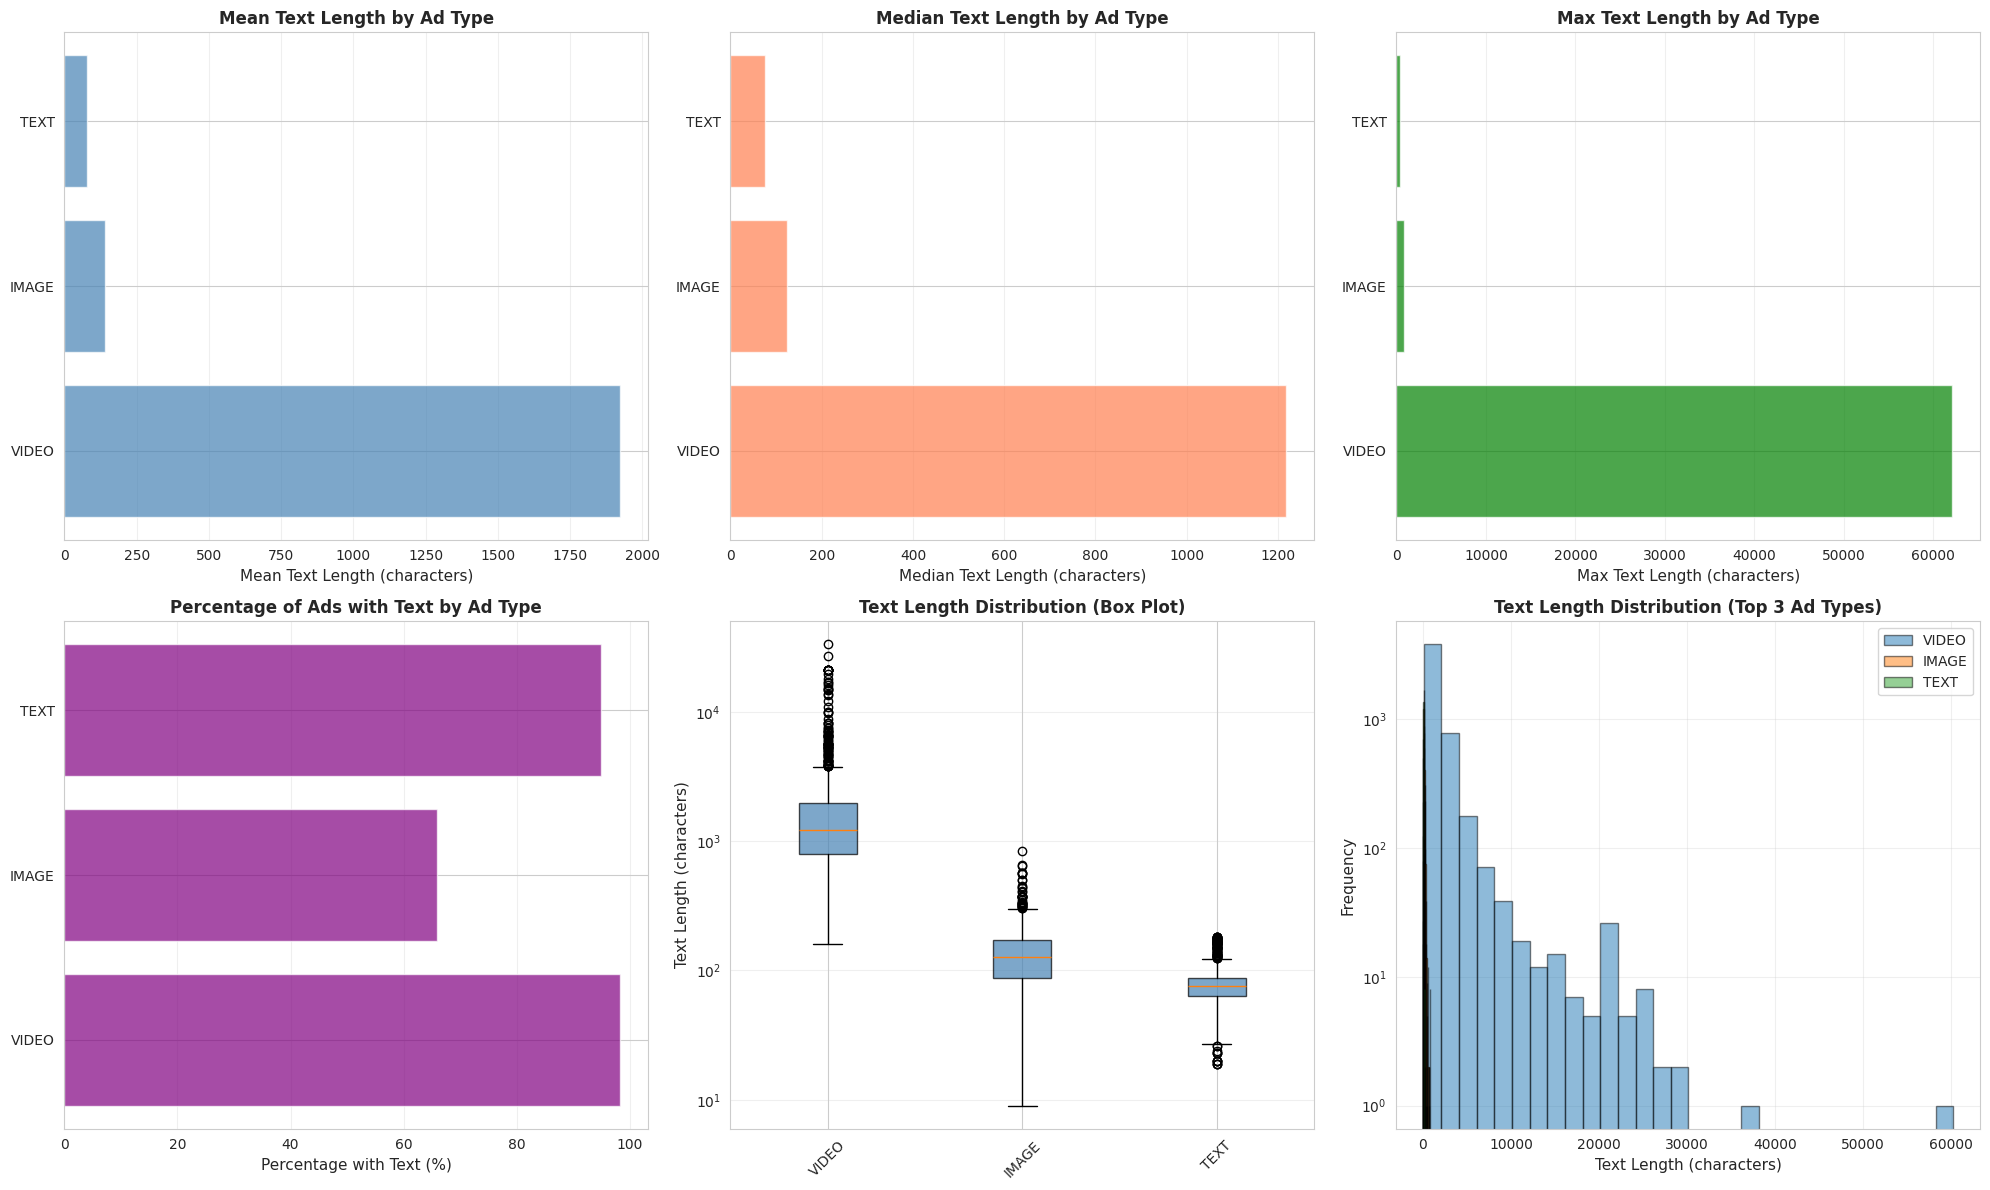


DETAILED TEXT LENGTH DISTRIBUTION BY AD TYPE

AD TYPE: VIDEO
Total ads: 36,271
Ads with text: 35,670

Text Length Statistics:
  Mean: 1924 characters
  Median: 1218 characters
  Std: 2717 characters
  Min: 14 characters
  Max: 62116 characters

Percentiles:
  25th: 810 characters
  50th (Median): 1218 characters
  75th: 1955 characters
  90th: 3541 characters
  95th: 5258 characters
  99th: 17846 characters

Length Categories:
  < 50 chars: 2 (0.0%)
  50-100 chars: 16 (0.0%)
  100-500 chars: 2,840 (8.0%)
  500-1000 chars: 10,329 (29.0%)
  >= 1000 chars: 22,483 (63.0%)


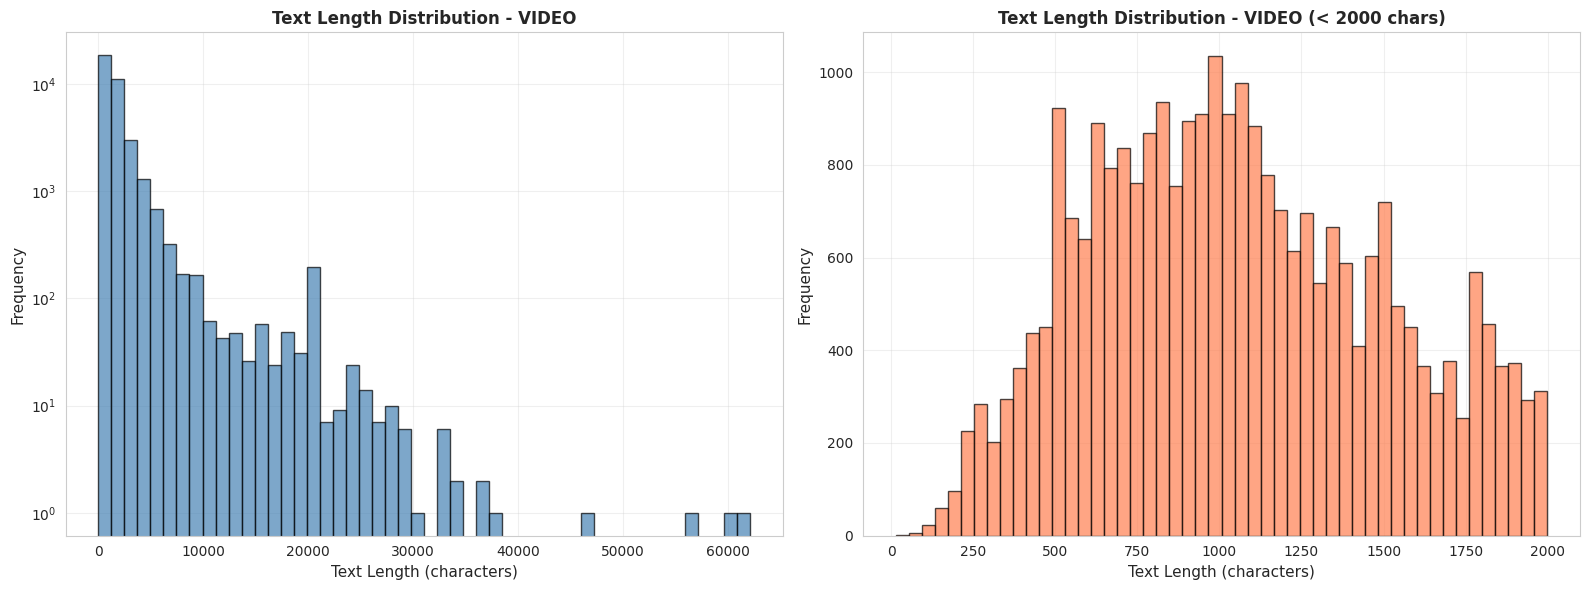


AD TYPE: IMAGE
Total ads: 28,153
Ads with text: 18,570

Text Length Statistics:
  Mean: 139 characters
  Median: 123 characters
  Std: 78 characters
  Min: 3 characters
  Max: 833 characters

Percentiles:
  25th: 80 characters
  50th (Median): 123 characters
  75th: 171 characters
  90th: 229 characters
  95th: 271 characters
  99th: 413 characters

Length Categories:
  < 50 chars: 282 (1.5%)
  50-100 chars: 6,311 (34.0%)
  100-500 chars: 11,855 (63.8%)
  500-1000 chars: 122 (0.7%)
  >= 1000 chars: 0 (0.0%)


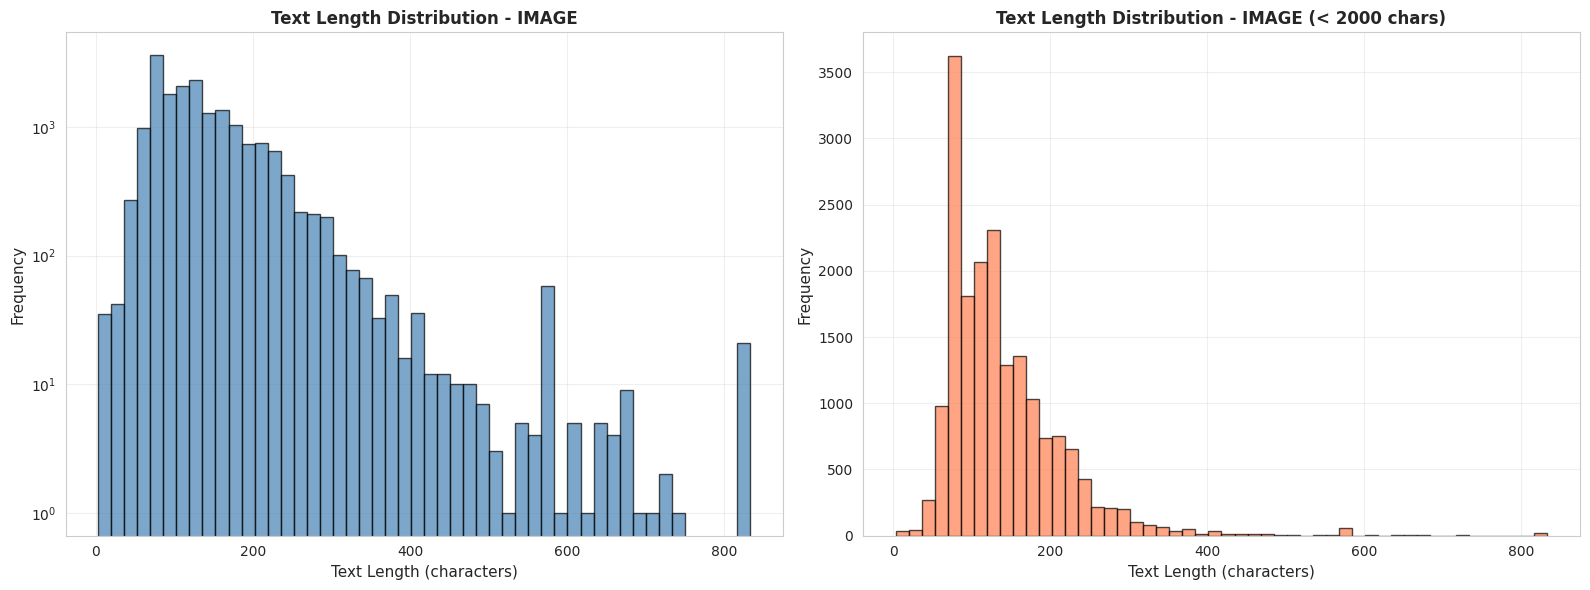


AD TYPE: TEXT
Total ads: 15,823
Ads with text: 15,030

Text Length Statistics:
  Mean: 79 characters
  Median: 76 characters
  Std: 29 characters
  Min: 9 characters
  Max: 357 characters

Percentiles:
  25th: 65 characters
  50th (Median): 76 characters
  75th: 87 characters
  90th: 90 characters
  95th: 152 characters
  99th: 178 characters

Length Categories:
  < 50 chars: 1,015 (6.8%)
  50-100 chars: 12,569 (83.6%)
  100-500 chars: 1,446 (9.6%)
  500-1000 chars: 0 (0.0%)
  >= 1000 chars: 0 (0.0%)


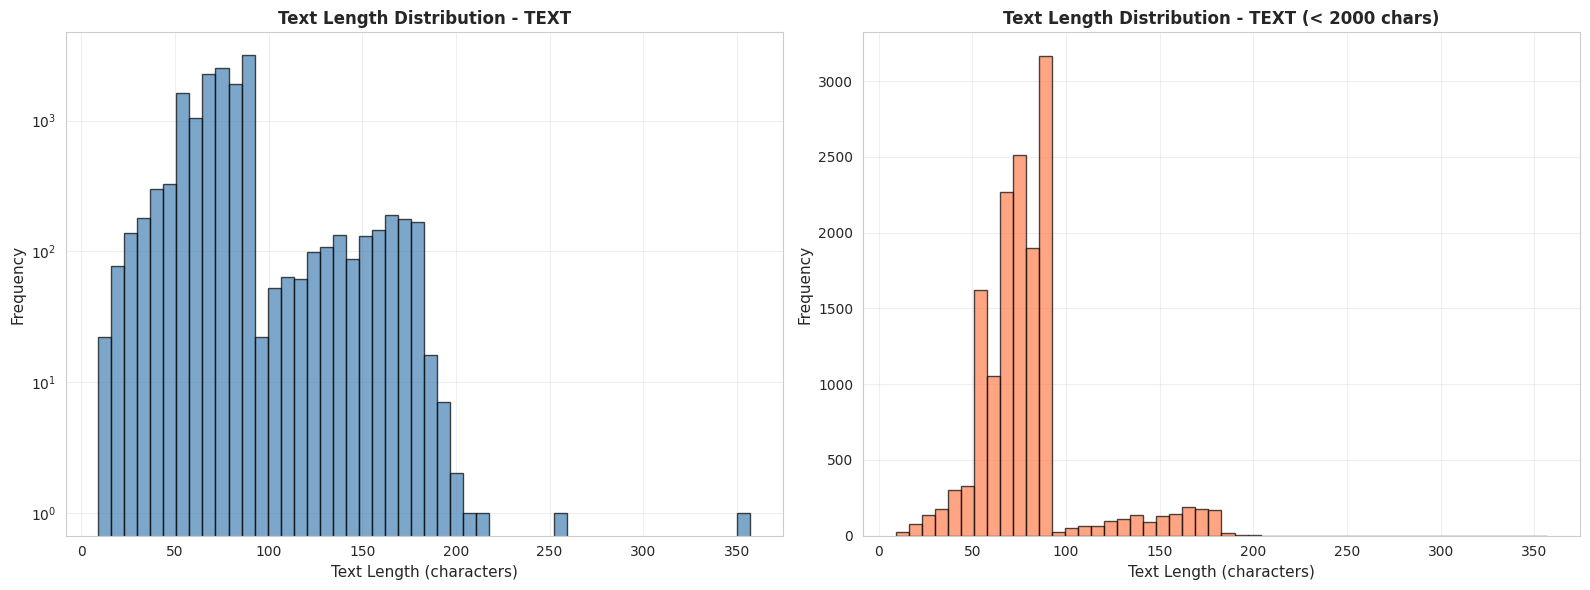


SUMMARY COMPARISON ACROSS AD TYPES

Key Insights:
  - Ad type with highest mean text length: VIDEO (1924 chars)
  - Ad type with lowest mean text length: TEXT (79 chars)
  - Ad type with highest text availability: VIDEO (98.3%)
  - Ad type with most total text: VIDEO (max: 62116 chars)


In [14]:
# TEXT LENGTH DISTRIBUTION BY MEDIA TYPE (AD_TYPE)
# Combining all text sources: ad_text, description, google_asr_text, aws_ocr_img_text, aws_ocr_video_text
print("=" * 80)
print("TEXT LENGTH DISTRIBUTION BY MEDIA TYPE (AD_TYPE)")
print("=" * 80)
print("Combining all text sources: ad_text, description, google_asr_text, aws_ocr_img_text, aws_ocr_video_text")

if 'ad_type' in df.columns:
    # Function to combine all text sources
    def combine_all_text_sources(row):
        """Combine all text sources into one field"""
        texts = []
        
        # Add all text sources
        text_sources = ['ad_text', 'description', 'google_asr_text', 'aws_ocr_img_text', 'aws_ocr_video_text']
        
        for col in text_sources:
            if col in df.columns:
                val = row.get(col)
                if pd.notna(val) and str(val).strip() != '':
                    texts.append(str(val).strip())
        
        return ' '.join(texts) if texts else ''
    
    # Create combined text for all rows
    df['all_text_combined'] = df.apply(combine_all_text_sources, axis=1)
    df['all_text_length'] = df['all_text_combined'].str.len()
    
    # Get ad types
    ad_types = df['ad_type'].dropna().unique()
    
    print(f"\nAd Types found: {list(ad_types)}")
    print(f"\nAnalyzing text length distribution for each ad type...\n")
    
    # Analyze each ad type
    distribution_data = []
    
    for ad_type in ad_types:
        type_df = df[df['ad_type'] == ad_type].copy()
        type_df_with_text = type_df[type_df['all_text_length'] > 0]
        
        if len(type_df_with_text) > 0:
            lengths = type_df_with_text['all_text_length']
            
            distribution_data.append({
                'Ad_Type': ad_type,
                'Total_Ads': len(type_df),
                'Ads_With_Text': len(type_df_with_text),
                'Ads_With_Text_Pct': (len(type_df_with_text) / len(type_df)) * 100,
                'Mean_Length': lengths.mean(),
                'Median_Length': lengths.median(),
                'Min_Length': lengths.min(),
                'Max_Length': lengths.max(),
                'Std_Length': lengths.std(),
                'Q25': lengths.quantile(0.25),
                'Q75': lengths.quantile(0.75),
                'Q90': lengths.quantile(0.90),
                'Q95': lengths.quantile(0.95)
            })
    
    dist_df = pd.DataFrame(distribution_data)
    dist_df = dist_df.sort_values('Total_Ads', ascending=False)
    
    print("=" * 80)
    print("TEXT LENGTH STATISTICS BY AD TYPE")
    print("=" * 80)
    print(dist_df.to_string(index=False))
    
    # Visualize distributions
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Mean text length by ad type
    axes[0, 0].barh(dist_df['Ad_Type'], dist_df['Mean_Length'], color='steelblue', alpha=0.7)
    axes[0, 0].set_xlabel('Mean Text Length (characters)', fontsize=11)
    axes[0, 0].set_title('Mean Text Length by Ad Type', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    
    # 2. Median text length by ad type
    axes[0, 1].barh(dist_df['Ad_Type'], dist_df['Median_Length'], color='coral', alpha=0.7)
    axes[0, 1].set_xlabel('Median Text Length (characters)', fontsize=11)
    axes[0, 1].set_title('Median Text Length by Ad Type', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # 3. Max text length by ad type
    axes[0, 2].barh(dist_df['Ad_Type'], dist_df['Max_Length'], color='green', alpha=0.7)
    axes[0, 2].set_xlabel('Max Text Length (characters)', fontsize=11)
    axes[0, 2].set_title('Max Text Length by Ad Type', fontsize=12, fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3, axis='x')
    
    # 4. Percentage with text by ad type
    axes[1, 0].barh(dist_df['Ad_Type'], dist_df['Ads_With_Text_Pct'], color='purple', alpha=0.7)
    axes[1, 0].set_xlabel('Percentage with Text (%)', fontsize=11)
    axes[1, 0].set_title('Percentage of Ads with Text by Ad Type', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # 5. Box plot of text length distributions (sample for readability)
    box_data = []
    box_labels = []
    for ad_type in dist_df['Ad_Type'].head(5):  # Show top 5 ad types
        type_df = df[(df['ad_type'] == ad_type) & (df['all_text_length'] > 0)]
        if len(type_df) > 0:
            # Sample if too many points
            sample_size = min(1000, len(type_df))
            lengths = type_df['all_text_length'].sample(sample_size) if len(type_df) > sample_size else type_df['all_text_length']
            box_data.append(lengths.values)
            box_labels.append(ad_type)
    
    if box_data:
        bp = axes[1, 1].boxplot(box_data, labels=box_labels, vert=True, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('steelblue')
            patch.set_alpha(0.7)
        axes[1, 1].set_ylabel('Text Length (characters)', fontsize=11)
        axes[1, 1].set_title('Text Length Distribution (Box Plot)', fontsize=12, fontweight='bold')
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # 6. Histogram overlay for top ad types
    top_types = dist_df.head(3)['Ad_Type'].values
    for idx, ad_type in enumerate(top_types):
        type_df = df[(df['ad_type'] == ad_type) & (df['all_text_length'] > 0)]
        if len(type_df) > 0:
            sample_size = min(5000, len(type_df))
            lengths = type_df['all_text_length'].sample(sample_size) if len(type_df) > sample_size else type_df['all_text_length']
            axes[1, 2].hist(lengths, bins=30, alpha=0.5, label=ad_type, edgecolor='black')
    
    axes[1, 2].set_xlabel('Text Length (characters)', fontsize=11)
    axes[1, 2].set_ylabel('Frequency', fontsize=11)
    axes[1, 2].set_title('Text Length Distribution (Top 3 Ad Types)', fontsize=12, fontweight='bold')
    axes[1, 2].legend()
    axes[1, 2].set_yscale('log')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Detailed distribution analysis for each ad type
    print("\n" + "=" * 80)
    print("DETAILED TEXT LENGTH DISTRIBUTION BY AD TYPE")
    print("=" * 80)
    
    for ad_type in dist_df['Ad_Type']:
        type_df = df[(df['ad_type'] == ad_type) & (df['all_text_length'] > 0)]
        
        if len(type_df) > 0:
            lengths = type_df['all_text_length']
            
            print(f"\n{'='*80}")
            print(f"AD TYPE: {ad_type}")
            print(f"{'='*80}")
            print(f"Total ads: {len(df[df['ad_type'] == ad_type]):,}")
            print(f"Ads with text: {len(type_df):,}")
            print(f"\nText Length Statistics:")
            print(f"  Mean: {lengths.mean():.0f} characters")
            print(f"  Median: {lengths.median():.0f} characters")
            print(f"  Std: {lengths.std():.0f} characters")
            print(f"  Min: {lengths.min():.0f} characters")
            print(f"  Max: {lengths.max():.0f} characters")
            print(f"\nPercentiles:")
            print(f"  25th: {lengths.quantile(0.25):.0f} characters")
            print(f"  50th (Median): {lengths.quantile(0.50):.0f} characters")
            print(f"  75th: {lengths.quantile(0.75):.0f} characters")
            print(f"  90th: {lengths.quantile(0.90):.0f} characters")
            print(f"  95th: {lengths.quantile(0.95):.0f} characters")
            print(f"  99th: {lengths.quantile(0.99):.0f} characters")
            
            # Length categories
            print(f"\nLength Categories:")
            print(f"  < 50 chars: {((lengths < 50).sum()):,} ({(lengths < 50).sum()/len(lengths)*100:.1f}%)")
            print(f"  50-100 chars: {((lengths >= 50) & (lengths < 100)).sum():,} ({((lengths >= 50) & (lengths < 100)).sum()/len(lengths)*100:.1f}%)")
            print(f"  100-500 chars: {((lengths >= 100) & (lengths < 500)).sum():,} ({((lengths >= 100) & (lengths < 500)).sum()/len(lengths)*100:.1f}%)")
            print(f"  500-1000 chars: {((lengths >= 500) & (lengths < 1000)).sum():,} ({((lengths >= 500) & (lengths < 1000)).sum()/len(lengths)*100:.1f}%)")
            print(f"  >= 1000 chars: {(lengths >= 1000).sum():,} ({(lengths >= 1000).sum()/len(lengths)*100:.1f}%)")
            
            # Visualize individual distribution
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            
            # Histogram
            axes[0].hist(lengths, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
            axes[0].set_xlabel('Text Length (characters)', fontsize=11)
            axes[0].set_ylabel('Frequency', fontsize=11)
            axes[0].set_title(f'Text Length Distribution - {ad_type}', fontsize=12, fontweight='bold')
            axes[0].set_yscale('log')
            axes[0].grid(True, alpha=0.3)
            
            # Focus on shorter texts
            short_lengths = lengths[lengths < 2000]
            if len(short_lengths) > 0:
                axes[1].hist(short_lengths, bins=50, edgecolor='black', alpha=0.7, color='coral')
                axes[1].set_xlabel('Text Length (characters)', fontsize=11)
                axes[1].set_ylabel('Frequency', fontsize=11)
                axes[1].set_title(f'Text Length Distribution - {ad_type} (< 2000 chars)', fontsize=12, fontweight='bold')
                axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
    
    # Summary comparison
    print("\n" + "=" * 80)
    print("SUMMARY COMPARISON ACROSS AD TYPES")
    print("=" * 80)
    print("\nKey Insights:")
    print(f"  - Ad type with highest mean text length: {dist_df.loc[dist_df['Mean_Length'].idxmax(), 'Ad_Type']} ({dist_df['Mean_Length'].max():.0f} chars)")
    print(f"  - Ad type with lowest mean text length: {dist_df.loc[dist_df['Mean_Length'].idxmin(), 'Ad_Type']} ({dist_df['Mean_Length'].min():.0f} chars)")
    print(f"  - Ad type with highest text availability: {dist_df.loc[dist_df['Ads_With_Text_Pct'].idxmax(), 'Ad_Type']} ({dist_df['Ads_With_Text_Pct'].max():.1f}%)")
    print(f"  - Ad type with most total text: {dist_df.loc[dist_df['Max_Length'].idxmax(), 'Ad_Type']} (max: {dist_df['Max_Length'].max():.0f} chars)")
    
else:
    print("⚠️  'ad_type' column not found in dataset")


In [15]:
# VIDEO ADS WITH COMBINED TEXT - AROUND MEDIAN/AVERAGE LENGTH
print("=" * 80)
print("VIDEO ADS WITH COMBINED TEXT - AROUND MEDIAN/AVERAGE LENGTH")
print("=" * 80)

# Filter for video ads
video_ads = df[df['ad_type'].str.upper() == 'VIDEO'].copy()

if len(video_ads) > 0:
    print(f"\nTotal video ads: {len(video_ads):,}")
    
    # Use the combined text we already created (all_text_combined) or create it
    if 'all_text_combined' not in video_ads.columns:
        def combine_all_text_sources(row):
            """Combine all text sources into one field"""
            texts = []
            text_sources = ['ad_text', 'description', 'google_asr_text', 'aws_ocr_img_text', 'aws_ocr_video_text']
            for col in text_sources:
                if col in df.columns:
                    val = row.get(col)
                    if pd.notna(val) and str(val).strip() != '':
                        texts.append(str(val).strip())
            return ' '.join(texts) if texts else ''
        
        video_ads['all_text_combined'] = video_ads.apply(combine_all_text_sources, axis=1)
    
    video_ads['all_text_length'] = video_ads['all_text_combined'].str.len()
    
    # Filter to video ads with text
    video_ads_with_text = video_ads[video_ads['all_text_length'] > 0].copy()
    
    print(f"Video ads with text: {len(video_ads_with_text):,}")
    
    if len(video_ads_with_text) > 0:
        # Calculate median and mean
        median_length = video_ads_with_text['all_text_length'].median()
        mean_length = video_ads_with_text['all_text_length'].mean()
        
        print(f"\nMedian text length: {median_length:.0f} characters")
        print(f"Mean text length: {mean_length:.0f} characters")
        
        # Find ads around median/average (within 20% of median)
        tolerance = median_length * 0.2
        around_median = video_ads_with_text[
            (video_ads_with_text['all_text_length'] >= median_length - tolerance) &
            (video_ads_with_text['all_text_length'] <= median_length + tolerance)
        ].copy()
        
        # If not enough ads around median, expand to include mean
        if len(around_median) < 30:
            tolerance_mean = mean_length * 0.3
            around_mean = video_ads_with_text[
                (video_ads_with_text['all_text_length'] >= mean_length - tolerance_mean) &
                (video_ads_with_text['all_text_length'] <= mean_length + tolerance_mean)
            ].copy()
            # Combine and remove duplicates
            around_median = pd.concat([around_median, around_mean]).drop_duplicates(subset=['ad_id'])
        
        # If still not enough, get closest to median/mean
        if len(around_median) < 30:
            # Sort by distance from median
            video_ads_with_text['distance_from_median'] = abs(video_ads_with_text['all_text_length'] - median_length)
            closest_to_median = video_ads_with_text.nsmallest(30, 'distance_from_median')
            around_median = closest_to_median
        
        # Sample 30 ads (or all if less than 30)
        sample_size = min(30, len(around_median))
        selected_ads = around_median.sample(n=sample_size, random_state=42) if len(around_median) > sample_size else around_median
        
        # Sort by text length for better display
        selected_ads = selected_ads.sort_values('all_text_length')
        
        print(f"\nSelected {len(selected_ads)} video ads around median/average length")
        print(f"Text length range: {selected_ads['all_text_length'].min():.0f} - {selected_ads['all_text_length'].max():.0f} characters")
        print(f"Average of selected: {selected_ads['all_text_length'].mean():.0f} characters")
        
        # Display the ads
        print("\n" + "=" * 100)
        print("VIDEO ADS WITH COMBINED TEXT")
        print("=" * 100)
        
        for idx, (row_idx, row) in enumerate(selected_ads.iterrows(), 1):
            print("\n" + "=" * 100)
            print(f"VIDEO AD #{idx} of {len(selected_ads)}")
            print("=" * 100)
            print(f"Ad ID: {row.get('ad_id', 'N/A')}")
            print(f"Advertiser: {row.get('advertiser_name', 'N/A')}")
            print(f"Ad Type: {row.get('ad_type', 'N/A')}")
            print(f"Ad URL: {row.get('ad_url', 'N/A')}")
            print(f"Combined Text Length: {row['all_text_length']:.0f} characters")
            
            # Show the combined text
            if pd.notna(row.get('all_text_combined')) and str(row['all_text_combined']).strip() != '':
                print(f"\n📝 COMBINED TEXT (all sources):")
                print("-" * 100)
                print(str(row['all_text_combined']))
                print("-" * 100)
            
            # Show breakdown by source
            print(f"\n📊 TEXT SOURCE BREAKDOWN:")
            print("-" * 100)
            
            if pd.notna(row.get('ad_text')) and str(row['ad_text']).strip() != '':
                ad_text = str(row['ad_text'])
                print(f"  📝 ad_text: {len(ad_text)} chars")
                print(f"     {ad_text[:200]}{'...' if len(ad_text) > 200 else ''}")
            
            if pd.notna(row.get('description')) and str(row['description']).strip() != '':
                desc = str(row['description'])
                print(f"  📄 description: {len(desc)} chars")
                print(f"     {desc[:200]}{'...' if len(desc) > 200 else ''}")
            
            if pd.notna(row.get('google_asr_text')) and str(row['google_asr_text']).strip() != '':
                asr = str(row['google_asr_text'])
                print(f"  🎥 google_asr_text (Speech-to-Text): {len(asr)} chars")
                print(f"     {asr[:200]}{'...' if len(asr) > 200 else ''}")
            
            if pd.notna(row.get('aws_ocr_img_text')) and str(row['aws_ocr_img_text']).strip() != '':
                ocr_img = str(row['aws_ocr_img_text'])
                print(f"  🖼️  aws_ocr_img_text (OCR from Images): {len(ocr_img)} chars")
                print(f"     {ocr_img[:200]}{'...' if len(ocr_img) > 200 else ''}")
            
            if pd.notna(row.get('aws_ocr_video_text')) and str(row['aws_ocr_video_text']).strip() != '':
                ocr_vid = str(row['aws_ocr_video_text'])
                print(f"  🎬 aws_ocr_video_text (OCR from Video): {len(ocr_vid)} chars")
                print(f"     {ocr_vid[:200]}{'...' if len(ocr_vid) > 200 else ''}")
            
            if pd.notna(row.get('ad_title')) and str(row['ad_title']).strip() != '':
                print(f"  📌 ad_title: {row['ad_title']}")
            
            print("\n")
        
        # Summary statistics
        print("\n" + "=" * 100)
        print("SUMMARY OF SELECTED VIDEO ADS")
        print("=" * 100)
        print(f"Number of ads: {len(selected_ads):,}")
        print(f"\nText Length Statistics:")
        print(f"  Mean: {selected_ads['all_text_length'].mean():.0f} characters")
        print(f"  Median: {selected_ads['all_text_length'].median():.0f} characters")
        print(f"  Min: {selected_ads['all_text_length'].min():.0f} characters")
        print(f"  Max: {selected_ads['all_text_length'].max():.0f} characters")
        print(f"  Std: {selected_ads['all_text_length'].std():.0f} characters")
        
        # Text source availability
        print(f"\nText Source Availability in Selected Ads:")
        print(f"  Has ad_text: {(selected_ads['ad_text'].notna() & (selected_ads['ad_text'].astype(str).str.strip() != '')).sum():,}")
        print(f"  Has description: {(selected_ads['description'].notna() & (selected_ads['description'].astype(str).str.strip() != '')).sum():,}")
        print(f"  Has google_asr_text: {(selected_ads['google_asr_text'].notna() & (selected_ads['google_asr_text'].astype(str).str.strip() != '')).sum():,}")
        print(f"  Has aws_ocr_img_text: {(selected_ads['aws_ocr_img_text'].notna() & (selected_ads['aws_ocr_img_text'].astype(str).str.strip() != '')).sum():,}")
        print(f"  Has aws_ocr_video_text: {(selected_ads['aws_ocr_video_text'].notna() & (selected_ads['aws_ocr_video_text'].astype(str).str.strip() != '')).sum():,}")
        
    else:
        print("\n⚠️  No video ads with text found")
else:
    print("\n⚠️  No video ads found in dataset")
    print(f"Available ad types: {df['ad_type'].unique() if 'ad_type' in df.columns else 'N/A'}")


VIDEO ADS WITH COMBINED TEXT - AROUND MEDIAN/AVERAGE LENGTH

Total video ads: 36,271
Video ads with text: 35,670

Median text length: 1218 characters
Mean text length: 1924 characters

Selected 30 video ads around median/average length
Text length range: 976 - 1436 characters
Average of selected: 1139 characters

VIDEO ADS WITH COMBINED TEXT

VIDEO AD #1 of 30
Ad ID: CR14226384757687582721
Advertiser: Texans for Greg Abbott
Ad Type: VIDEO
Ad URL: https://adstransparency.google.com/advertiser/AR10418792552093188097/creative/CR14226384757687582721?political=&region=US
Combined Text Length: 976 characters

📝 COMBINED TEXT (all sources):
----------------------------------------------------------------------------------------------------
Joe Biden's inflation is crushing Americans, and Biden, and Beto support higher taxes. That would crush us even more. But in Texas, we are fighting back cutting property taxes to help homeowners producing more energy to lower gas prices and we passed a cons

## Summary and Key Findings

### Dataset Quality Assessment

1. **Missing Values:**
   - Comprehensive analysis of null and empty string values
   - Identification of columns with high missing data
   - Assessment of data completeness

2. **Text Source Analysis:**
   - **Actual Ad Text**: `ad_text`, `ad_title`, `description` - Original ad content
   - **Extracted Text**: `google_asr_text`, `aws_ocr_img_text`, `aws_ocr_video_text` - Machine-extracted content
   - Clear distinction between actual ad text and extracted text

3. **Data Quality Issues:**
   - Identification of potential problems
   - Assessment of text completeness
   - Evaluation of text quality metrics

### Text Content Analysis

1. **Text Availability:**
   - Percentage of ads with actual text vs extracted text
   - Overlap between actual and extracted text sources
   - Text length distributions

2. **Text Source Comparison:**
   - Actual ad text (primary content)
   - Speech-to-text from videos (ASR)
   - OCR from images
   - OCR from video frames

3. **Full Text Display:**
   - Complete text content shown for multiple ads
   - Clear labeling of text sources
   - Examples of different text types

### NLP Usability Assessment

1. **Usability Metrics:**
   - Percentage of ads with substantial text
   - Text length statistics
   - Quality indicators (punctuation, capitalization, etc.)

2. **Verdict:**
   - Assessment of whether dataset is suitable for NLP
   - Recommendations for using the data
   - Suggestions for data filtering/enhancement

### Additional Analyses

1. **Ad Type Analysis:**
   - Distribution of ad types
   - Text availability by ad type

2. **Advertiser Analysis:**
   - Top advertisers
   - Text availability by advertiser

3. **Basic NLP Features:**
   - Word count, sentence count
   - Text quality indicators
   - Feature distributions

### Recommendations

1. **For NLP Tasks:**
   - Use combined text field (prioritizes actual ad text)
   - Filter to ads with >100 characters for better quality
   - Consider supplementing with extracted text when actual text is missing

2. **For Manipulation Detection:**
   - Focus on actual ad text (`ad_text`) as primary source
   - Use extracted text (OCR/ASR) as supplementary information
   - Combine text features with metadata for comprehensive analysis

3. **Data Preprocessing:**
   - Handle missing values appropriately
   - Clean extracted text (may have OCR/ASR errors)
   - Normalize text length for analysis
